# Neural Networks from First Principles
## Build Fellowship — ML Foundations Series | Notebook 2

This notebook builds every concept by hand before handing it to a library.  
By the end you will have implemented forward passes, backpropagation, two loss functions,  
an autodiff engine, and two optimizers — all in NumPy — and you will have *seen* every  
equation in working code.

---

### What we cover

| Section | Topic |
|---------|-------|
| 0 | Environment setup & shared utilities |
| 1 | Logistic regression — sigmoid, decision boundary, gradient descent |
| 2 | Overfitting & underfitting with logistic regression |
| 3 | Single hidden-layer network — math + forward pass (4 neurons) |
| 4 | Two hidden-layer network — math + forward pass (3 → 2 neurons) |
| 5 | Manifold transformations — how each layer warps the input space |
| 6 | Chain rule — full symbolic + numerical derivation for the 2-layer net |
| 7 | Weight initialisation — why zero-init breaks everything |
| 8 | Computation graphs — tracing the forward pass explicitly |
| 9 | Gradient vanishing — what happens when you chain sigmoids |
| 10 | Loss functions — Binary Cross-Entropy and Mean Squared Error compared |
| 11 | Autodiff from scratch — a minimal reverse-mode engine in pure Python |
| 12 | Loss landscape — visualising the surface SGD must navigate |
| 13 | Optimisers — SGD vs SGD+Momentum, trajectory comparison |
| 14 | Batch sizes — full-batch, mini-batch, stochastic compared |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.colors as mcolors
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Shared plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {'pos': '#2196F3', 'neg': '#F44336', 'neutral': '#9E9E9E',
          'line': '#212121', 'accent': '#FF9800', 'green': '#4CAF50'}

print("✓ Environment ready  |  NumPy", np.__version__)


✓ Environment ready  |  NumPy 2.1.3


---
## Section 1 — Logistic Regression

### 1.1 The sigmoid function

The sigmoid maps any real number to (0, 1), giving us a probability:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Its derivative has a beautiful closed form:

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

This derivative will appear again in every backprop derivation we write.


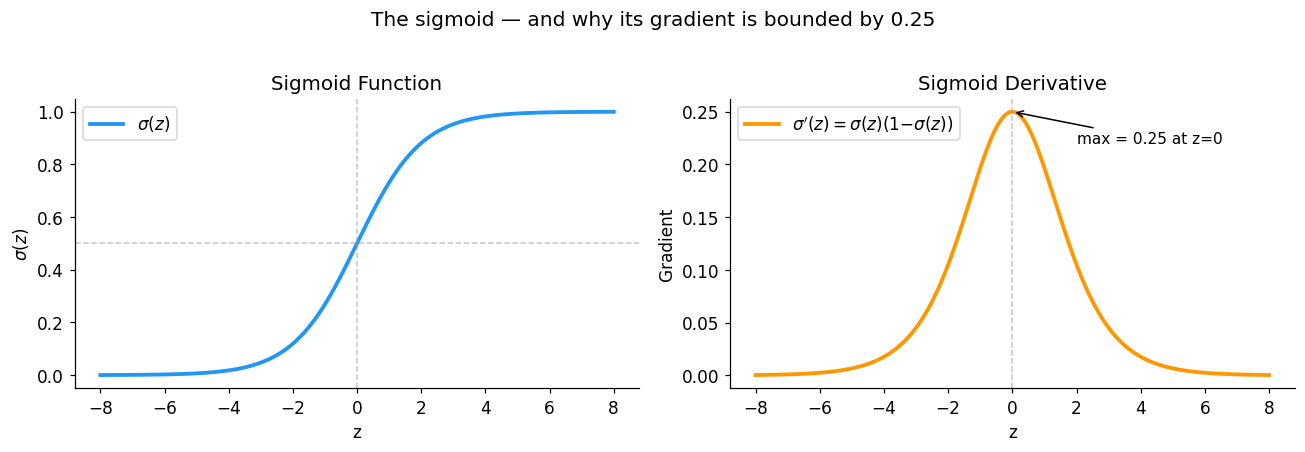

Key insight: sigmoid gradient is ALWAYS < 0.25.
We will return to this in Section 9 (gradient vanishing).


In [2]:
def sigmoid(z):
    """Numerically stable sigmoid."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

z = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, sigmoid(z), color=COLORS['pos'], lw=2.5, label=r'$\sigma(z)$')
axes[0].axhline(0.5, color=COLORS['neutral'], ls='--', lw=1, alpha=0.6)
axes[0].axvline(0,   color=COLORS['neutral'], ls='--', lw=1, alpha=0.6)
axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$\sigma(z)$')
axes[0].set_title('Sigmoid Function')
axes[0].legend()

axes[1].plot(z, sigmoid_deriv(z), color=COLORS['accent'], lw=2.5,
             label=r"$\sigma'(z) = \sigma(z)(1{-}\sigma(z))$")
axes[1].axvline(0, color=COLORS['neutral'], ls='--', lw=1, alpha=0.6)
axes[1].set_xlabel('z'); axes[1].set_ylabel("Gradient")
axes[1].set_title('Sigmoid Derivative')
axes[1].legend()

# Annotate maximum gradient
max_idx = np.argmax(sigmoid_deriv(z))
axes[1].annotate(f'max = 0.25 at z=0',
                 xy=(0, 0.25), xytext=(2, 0.22),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10)

plt.suptitle('The sigmoid — and why its gradient is bounded by 0.25', y=1.02)
plt.tight_layout()
plt.show()
print("Key insight: sigmoid gradient is ALWAYS < 0.25.")
print("We will return to this in Section 9 (gradient vanishing).")


### 1.2 Logistic regression — building the classifier from scratch

**Model:**  $\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b)$

**Loss (Binary Cross-Entropy):**

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

**Gradient update:**

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{N} \mathbf{X}^\top (\hat{y} - y), \qquad
\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N}\sum(\hat{y} - y)$$


Train accuracy: 0.921  |  Test accuracy: 0.950


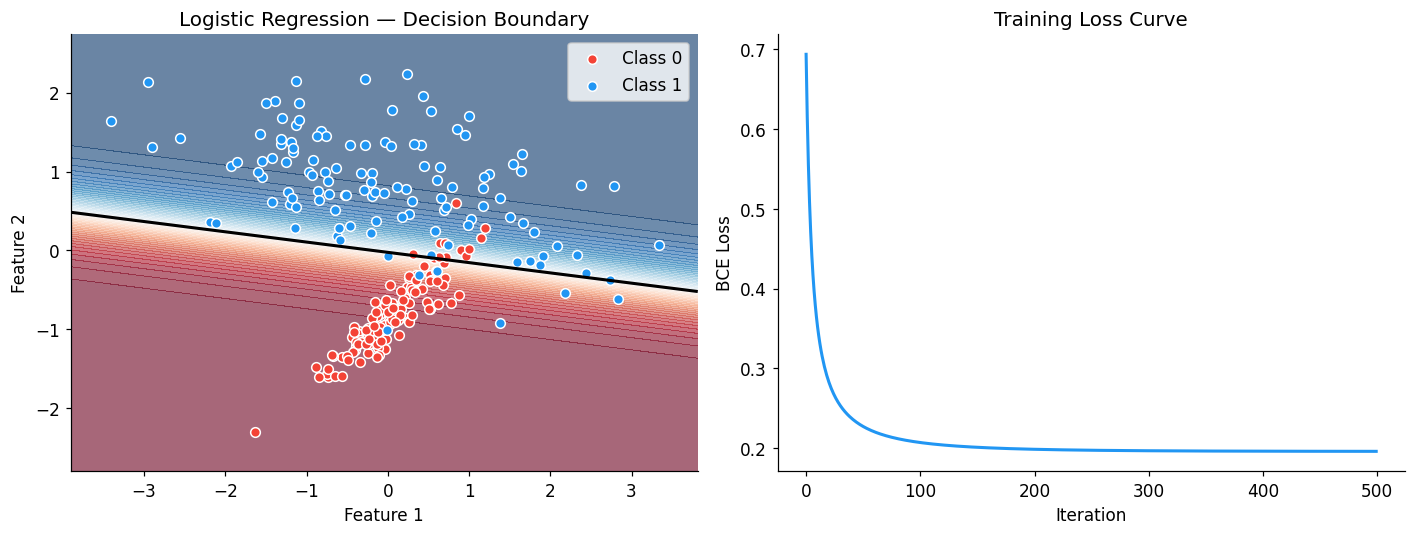

In [3]:
class LogisticRegression:
    """Hand-rolled logistic regression"""

    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.losses = []

    def _bce_loss(self, y_hat, y):
        eps = 1e-12  # numerical safety
        return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # ── Small random init (not zero — more on this in Section 7) ───────────
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0
        self.losses = []

        for _ in range(self.n_iters):
            # Forward pass
            z     = X @ self.w + self.b
            y_hat = sigmoid(z)

            # Loss
            loss = self._bce_loss(y_hat, y)
            self.losses.append(loss)

            # Backward pass — derived from dL/dw = X^T (y_hat - y) / N
            error = y_hat - y
            dw    = (X.T @ error) / n_samples
            db    = np.mean(error)

            # Update
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# ── Dataset ───────────────────────────────────────────────────────────────────
np.random.seed(SEED)
X_lin, y_lin = make_classification(n_samples=300, n_features=2,
                                    n_redundant=0, n_informative=2,
                                    random_state=SEED, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X_lin, y_lin,
                                                     test_size=0.2,
                                                     random_state=SEED,
                                                     stratify=y_lin)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Train ──────────────────────────────────────────────────────────────────────
lr_model = LogisticRegression(lr=0.5, n_iters=500)
lr_model.fit(X_train, y_train)

train_acc = np.mean(lr_model.predict(X_train) == y_train)
test_acc  = np.mean(lr_model.predict(X_test)  == y_test)
print(f"Train accuracy: {train_acc:.3f}  |  Test accuracy: {test_acc:.3f}")

# ── Plot: decision boundary + loss curve ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Decision boundary
h = 0.02
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = lr_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
axes[0].contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
axes[0].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
                c=COLORS['neg'], edgecolors='white', s=40, label='Class 0')
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
                c=COLORS['pos'], edgecolors='white', s=40, label='Class 1')
axes[0].set_title('Logistic Regression — Decision Boundary')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].legend()

# Loss curve
axes[1].plot(lr_model.losses, color=COLORS['pos'], lw=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Training Loss Curve')

plt.tight_layout()
plt.show()


---
## Section 2 — Overfitting & Underfitting

We use **polynomial feature expansion** to show the full bias-variance spectrum  
with a single logistic regression model:

| Degree | Model capacity | Expected behaviour |
|--------|---------------|-------------------|
| 1 | Low | Underfitting — high bias |
| 3 | Medium | Good generalisation |
| 10+ | High | Overfitting — high variance |

The non-linear dataset (two moons) forces us to add features to separate the classes.


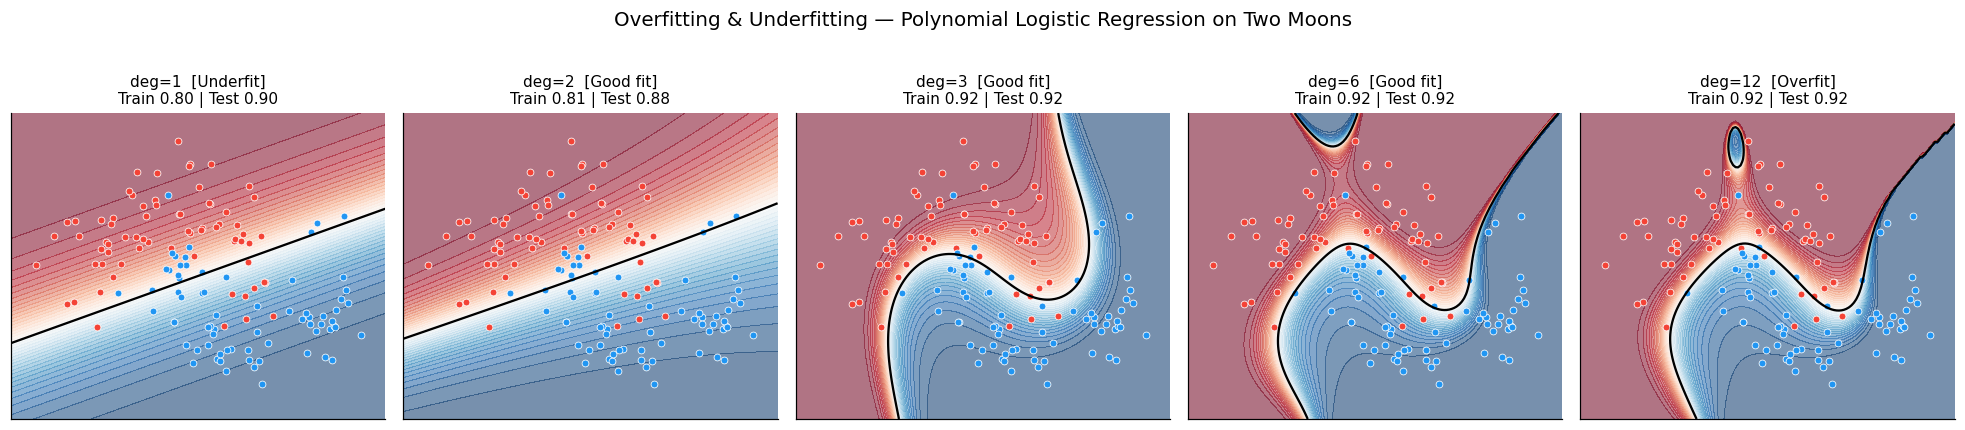

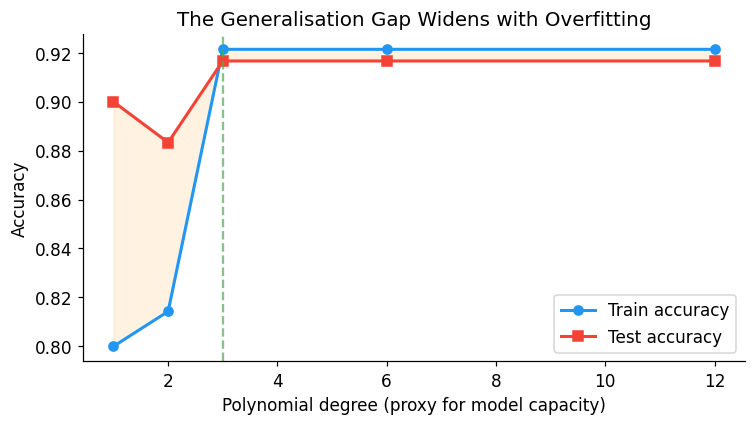

The gap between train and test accuracy IS the generalisation gap.
High gap → overfitting.  Low train AND test accuracy → underfitting.


In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.random.seed(SEED)
X_m, y_m = make_moons(n_samples=200, noise=0.25, random_state=SEED)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_m, y_m, test_size=0.3,
                                                    random_state=SEED,
                                                    stratify=y_m)

degrees = [1, 2, 3, 6, 12]
train_accs, test_accs = [], []

fig, axes = plt.subplots(1, len(degrees), figsize=(18, 3.8), sharey=True)

h = 0.03
x0_min, x0_max = X_m[:, 0].min() - 0.3, X_m[:, 0].max() + 0.3
x1_min, x1_max = X_m[:, 1].min() - 0.3, X_m[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))

for ax, deg in zip(axes, degrees):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
    ])
    X_tr_p = pipe.fit_transform(X_m_tr)
    X_te_p = pipe.transform(X_m_te)
    X_gr_p = pipe.transform(np.c_[xx.ravel(), yy.ravel()])

    model = LogisticRegression(lr=0.3, n_iters=2000)
    model.fit(X_tr_p, y_m_tr)

    tr_acc = np.mean(model.predict(X_tr_p) == y_m_tr)
    te_acc = np.mean(model.predict(X_te_p) == y_m_te)
    train_accs.append(tr_acc); test_accs.append(te_acc)

    Z = model.predict_proba(X_gr_p).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=40, cmap='RdBu', alpha=0.55)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_m_tr[y_m_tr==0, 0], X_m_tr[y_m_tr==0, 1],
               c=COLORS['neg'], s=20, edgecolors='white', lw=0.5)
    ax.scatter(X_m_tr[y_m_tr==1, 0], X_m_tr[y_m_tr==1, 1],
               c=COLORS['pos'], s=20, edgecolors='white', lw=0.5)

    label = 'Underfit' if deg == 1 else ('Overfit' if deg == 12 else 'Good fit')
    ax.set_title(f'deg={deg}  [{label}]\nTrain {tr_acc:.2f} | Test {te_acc:.2f}',
                 fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Overfitting & Underfitting — Polynomial Logistic Regression on Two Moons',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# ── Generalisation gap plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degrees, train_accs, 'o-', color=COLORS['pos'],  lw=2, label='Train accuracy')
ax.plot(degrees, test_accs,  's-', color=COLORS['neg'],  lw=2, label='Test accuracy')
ax.fill_between(degrees, train_accs, test_accs, alpha=0.12, color=COLORS['accent'])
ax.set_xlabel('Polynomial degree (proxy for model capacity)')
ax.set_ylabel('Accuracy')
ax.set_title('The Generalisation Gap Widens with Overfitting')
ax.legend()
ax.axvline(3, color=COLORS['green'], ls='--', alpha=0.7, label='Sweet spot')
plt.tight_layout()
plt.show()
print("The gap between train and test accuracy IS the generalisation gap.")
print("High gap → overfitting.  Low train AND test accuracy → underfitting.")


---
## Section 3 — Single Hidden-Layer Network

### Architecture: 2 → 4 → 1

```
Input layer        Hidden layer        Output layer
  x₁  ──┐          h₁
         ├── w¹ →  h₂  ── w² → ŷ
  x₂  ──┘          h₃
                    h₄
```

### Forward pass math

**Layer 1** (input → hidden):

$$\mathbf{z}^{[1]} = \mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}, \qquad \mathbf{a}^{[1]} = \sigma(\mathbf{z}^{[1]})$$

where $\mathbf{W}^{[1]} \in \mathbb{R}^{4 \times 2}$, $\mathbf{b}^{[1]} \in \mathbb{R}^{4}$.

**Layer 2** (hidden → output):

$$z^{[2]} = \mathbf{W}^{[2]}\mathbf{a}^{[1]} + b^{[2]}, \qquad \hat{y} = \sigma(z^{[2]})$$

where $\mathbf{W}^{[2]} \in \mathbb{R}^{1 \times 4}$, $b^{[2]} \in \mathbb{R}$.

**Total parameters:** $(2 \times 4 + 4) + (4 \times 1 + 1) = 17$


In [5]:
def relu(z):    return np.maximum(0, z)
def relu_deriv(z): return (z > 0).astype(float)

def tanh_deriv(z): return 1 - np.tanh(z)**2

def init_weights(shape, seed=SEED):
    """He initialisation — correct default for ReLU layers."""
    np.random.seed(seed)
    fan_in = shape[1] if len(shape) > 1 else shape[0]
    return np.random.randn(*shape) * np.sqrt(2.0 / fan_in)


class TwoLayerNet:
    """
    Architecture: n_in → n_hidden → 1
    Every matrix multiply is written out explicitly so you can follow the shapes.
    """

    def __init__(self, n_in, n_hidden, activation='sigmoid'):
        self.act   = {'sigmoid': sigmoid,   'relu': relu,   'tanh': np.tanh}[activation]
        self.dact  = {'sigmoid': sigmoid_deriv, 'relu': relu_deriv,
                      'tanh': tanh_deriv}[activation]
        # Weights
        self.W1 = init_weights((n_hidden, n_in))
        self.b1 = np.zeros(n_hidden)
        self.W2 = init_weights((1, n_hidden))
        self.b2 = np.zeros(1)
        # Cache for backprop
        self.cache = {}

    def forward(self, X):
        """X shape: (n_samples, n_in)"""
        # Layer 1
        Z1 = X @ self.W1.T + self.b1          # (N, n_hidden)
        A1 = self.act(Z1)                      # (N, n_hidden)
        # Layer 2
        Z2 = A1 @ self.W2.T + self.b2         # (N, 1)
        A2 = sigmoid(Z2)                       # (N, 1) — output is always sigmoid
        # Cache
        self.cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
        return A2.squeeze()


# ── Demonstrate forward pass shapes ──────────────────────────────────────────
net_1h = TwoLayerNet(n_in=2, n_hidden=4)
x_demo = np.array([[0.3, -0.7], [1.2, 0.5]])
out    = net_1h.forward(x_demo)

print("=== Single Hidden-Layer Forward Pass ===")
print(f"  Input  X  : {x_demo.shape}  →  values: {x_demo}")
print(f"  W1 shape  : {net_1h.W1.shape}  (4 neurons × 2 inputs)")
print(f"  Z1 = X·W1ᵀ + b1  shape: {net_1h.cache['Z1'].shape}")
print(f"  A1 = σ(Z1) shape: {net_1h.cache['A1'].shape}")
print(f"  W2 shape  : {net_1h.W2.shape}  (1 output × 4 hidden)")
print(f"  Z2 shape  : {net_1h.cache['Z2'].shape}")
print(f"  ŷ = σ(Z2) : {out}")
print()
total_params = net_1h.W1.size + net_1h.b1.size + net_1h.W2.size + net_1h.b2.size
print(f"Total parameters: {total_params}")


=== Single Hidden-Layer Forward Pass ===
  Input  X  : (2, 2)  →  values: [[ 0.3 -0.7]
 [ 1.2  0.5]]
  W1 shape  : (4, 2)  (4 neurons × 2 inputs)
  Z1 = X·W1ᵀ + b1  shape: (2, 4)
  A1 = σ(Z1) shape: (2, 4)
  W2 shape  : (1, 4)  (1 output × 4 hidden)
  Z2 shape  : (2, 1)
  ŷ = σ(Z2) : [0.71694652 0.78604711]

Total parameters: 17


---
## Section 4 — Two Hidden-Layer Network

### Architecture: 2 → 3 → 2 → 1

```
Input        Hidden-1     Hidden-2     Output
  x₁  ─┐      h₁¹          h₁²
        ├─W¹→  h₂¹  ─W²→   h₂²  ─W³→  ŷ
  x₂  ─┘      h₃¹
```

### Full forward pass

$$\mathbf{z}^{[1]} = \mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}, \quad \mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]})$$

$$\mathbf{z}^{[2]} = \mathbf{W}^{[2]}\mathbf{a}^{[1]} + \mathbf{b}^{[2]}, \quad \mathbf{a}^{[2]} = \text{ReLU}(\mathbf{z}^{[2]})$$

$$z^{[3]} = \mathbf{W}^{[3]}\mathbf{a}^{[2]} + b^{[3]}, \quad \hat{y} = \sigma(z^{[3]})$$

**Parameter count:**
- Layer 1: $2 \times 3 + 3 = 9$
- Layer 2: $3 \times 2 + 2 = 8$
- Layer 3: $2 \times 1 + 1 = 3$
- **Total: 20 parameters**


In [6]:
class ThreeLayerNet:
    """
    Architecture: n_in → h1 → h2 → 1
    Hidden layers use ReLU. Output uses sigmoid.
    All intermediate values cached for backprop.
    """

    def __init__(self, n_in=2, h1=3, h2=2):
        self.W1 = init_weights((h1, n_in));   self.b1 = np.zeros(h1)
        self.W2 = init_weights((h2, h1));     self.b2 = np.zeros(h2)
        self.W3 = init_weights((1,  h2));     self.b3 = np.zeros(1)
        self.cache = {}

    def forward(self, X):
        """Full forward pass with shape annotations."""
        # Layer 1: (N,2)→(N,3)
        Z1 = X  @ self.W1.T + self.b1    # (N, 3)
        A1 = relu(Z1)                    # (N, 3)
        # Layer 2: (N,3)→(N,2)
        Z2 = A1 @ self.W2.T + self.b2   # (N, 2)
        A2 = relu(Z2)                    # (N, 2)
        # Layer 3: (N,2)→(N,1)
        Z3 = A2 @ self.W3.T + self.b3   # (N, 1)
        A3 = sigmoid(Z3)                 # (N, 1)

        self.cache = dict(X=X, Z1=Z1, A1=A1, Z2=Z2, A2=A2, Z3=Z3, A3=A3)
        return A3.squeeze()

    def param_count(self):
        params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]
        return sum(p.size for p in params)


# ── Trace a single forward pass ───────────────────────────────────────────────
net = ThreeLayerNet(n_in=2, h1=3, h2=2)
x_s = np.array([[1.0, -0.5]])

out = net.forward(x_s)
c   = net.cache

print("=== Two Hidden-Layer Network — Forward Pass Trace ===\n")
print(f"Input  x       = {x_s}  shape {x_s.shape}")
print()
print(f"[Layer 1]  Z1 = x · W1ᵀ + b1")
print(f"  W1  shape: {net.W1.shape}   b1  shape: {net.b1.shape}")
print(f"  Z1  = {c['Z1']}   shape {c['Z1'].shape}")
print(f"  A1  = ReLU(Z1) = {c['A1']}   shape {c['A1'].shape}")
print()
print(f"[Layer 2]  Z2 = A1 · W2ᵀ + b2")
print(f"  W2  shape: {net.W2.shape}   b2  shape: {net.b2.shape}")
print(f"  Z2  = {c['Z2']}   shape {c['Z2'].shape}")
print(f"  A2  = ReLU(Z2) = {c['A2']}   shape {c['A2'].shape}")
print()
print(f"[Layer 3]  Z3 = A2 · W3ᵀ + b3")
print(f"  W3  shape: {net.W3.shape}   b3  shape: {net.b3.shape}")
print(f"  Z3  = {c['Z3']}   shape {c['Z3'].shape}")
print(f"  ŷ   = σ(Z3) = {out:.6f}")
print()
print(f"Total parameters: {net.param_count()}")


=== Two Hidden-Layer Network — Forward Pass Trace ===

Input  x       = [[ 1.  -0.5]]  shape (1, 2)

[Layer 1]  Z1 = x · W1ᵀ + b1
  W1  shape: (3, 2)   b1  shape: (3,)
  Z1  = [[ 0.5658463  -0.11382639 -0.1170849 ]]   shape (1, 3)
  A1  = ReLU(Z1) = [[0.5658463 0.        0.       ]]   shape (1, 3)

[Layer 2]  Z2 = A1 · W2ᵀ + b2
  W2  shape: (2, 3)   b2  shape: (2,)
  Z2  = [[0.22948769 0.70365742]]   shape (1, 2)
  A2  = ReLU(Z2) = [[0.22948769 0.70365742]]   shape (1, 2)

[Layer 3]  Z3 = A2 · W3ᵀ + b3
  W3  shape: (1, 2)   b3  shape: (1,)
  Z3  = [[0.01669908]]   shape (1, 1)
  ŷ   = σ(Z3) = 0.504175

Total parameters: 20


---
## Section 5 — Manifold Transformations: How Each Layer Warps Space

This is one of the most important geometric intuitions in deep learning.

A neural network learns by **bending and folding the input space** until  
classes that were tangled in input space become linearly separable at the output.

Each layer applies:
1. A **linear transformation** (matrix multiply) — rotates, scales, shears the space
2. A **nonlinearity** (ReLU/sigmoid) — folds or clips the space

We visualise this on the two-moons dataset, tracking a grid of points  
through each transformation to see how the manifold changes.


ManifoldNet trained.


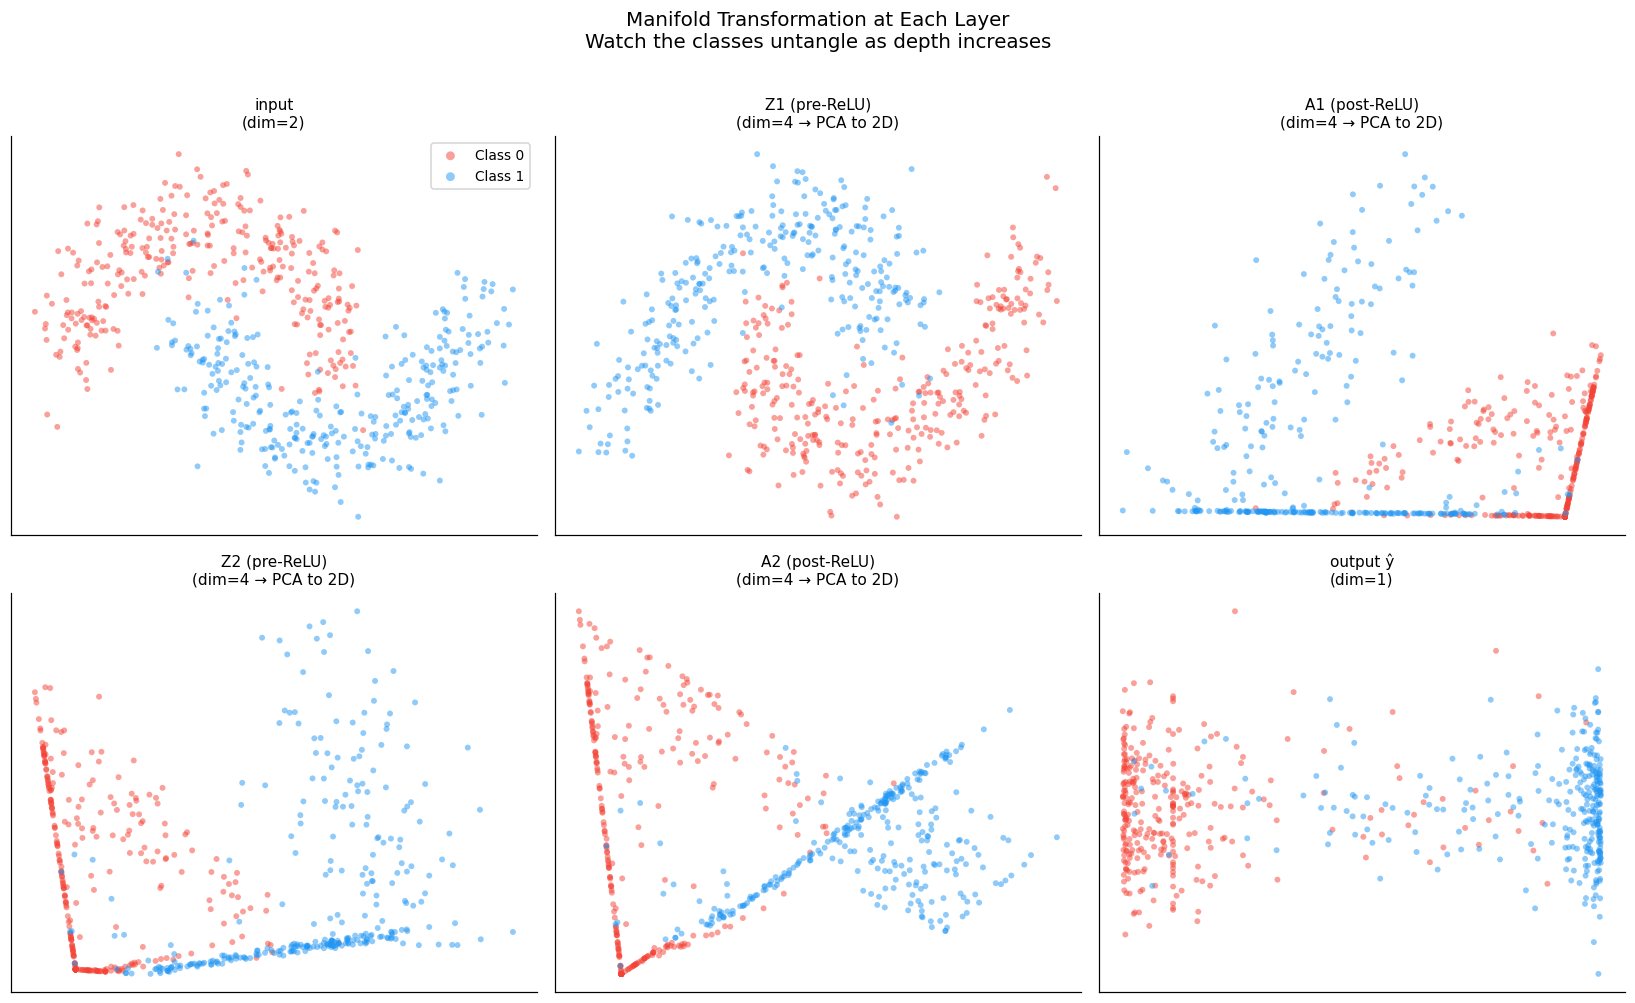

Classes are tangled in input space; the network unravels them layer by layer.


In [7]:
np.random.seed(SEED)
X_vis, y_vis = make_moons(n_samples=600, noise=0.18, random_state=SEED)
scaler_vis = StandardScaler()
X_vis = scaler_vis.fit_transform(X_vis)

class ManifoldNet:
    """Wider network to show manifold warping layer by layer."""
    def __init__(self):
        np.random.seed(SEED)
        self.W1 = np.random.randn(4, 2) * 0.5;  self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 4) * 0.5;  self.b2 = np.zeros(4)
        self.W3 = np.random.randn(1, 4) * 0.5;  self.b3 = np.zeros(1)

    def transforms(self, X):
        """Return intermediate representations at every stage."""
        Z1 = X  @ self.W1.T + self.b1;  A1 = relu(Z1)
        Z2 = A1 @ self.W2.T + self.b2;  A2 = relu(Z2)
        Z3 = A2 @ self.W3.T + self.b3;  A3 = sigmoid(Z3)
        return {'input': X, 'Z1 (pre-ReLU)': Z1, 'A1 (post-ReLU)': A1,
                'Z2 (pre-ReLU)': Z2, 'A2 (post-ReLU)': A2, 'output ŷ': A3}

    def forward(self, X):
        return self.transforms(X)['output ŷ'].squeeze()

    def fit(self, X, y, lr=0.05, iters=4000):
        """Gradient descent — full backprop."""
        N = len(y)
        for _ in range(iters):
            t   = self.transforms(X)
            A3  = t['output ŷ'].squeeze()
            eps = 1e-12
            dA3 = -(y / (A3 + eps) - (1 - y) / (1 - A3 + eps)) / N
            Z3  = t['Z2 (pre-ReLU)']  # reuse variable — Z3 is W3·A2+b3
            A2  = t['A2 (post-ReLU)']
            Z3_actual = A2 @ self.W3.T + self.b3
            dZ3 = dA3[:, None] * sigmoid_deriv(Z3_actual)
            dW3 = dZ3.T @ A2;   db3 = dZ3.sum(axis=0)
            dA2 = dZ3 @ self.W3
            Z2  = t['Z2 (pre-ReLU)']
            dZ2 = dA2 * relu_deriv(Z2)
            dW2 = dZ2.T @ t['A1 (post-ReLU)'];  db2 = dZ2.sum(axis=0)
            dA1 = dZ2 @ self.W2
            Z1  = t['Z1 (pre-ReLU)']
            dZ1 = dA1 * relu_deriv(Z1)
            dW1 = dZ1.T @ X;  db1 = dZ1.sum(axis=0)
            self.W3 -= lr*dW3; self.b3 -= lr*db3
            self.W2 -= lr*dW2; self.b2 -= lr*db2
            self.W1 -= lr*dW1; self.b1 -= lr*db1


def pca_2d(M):
    """Manual 2-component PCA — no sklearn needed."""
    M_c = M - M.mean(axis=0)
    cov = M_c.T @ M_c
    vals, vecs = np.linalg.eigh(cov)
    idx = np.argsort(vals)[::-1][:2]
    return M_c @ vecs[:, idx]


mnet = ManifoldNet()
mnet.fit(X_vis, y_vis, lr=0.05, iters=4000)
print("ManifoldNet trained.")

# ── Visualise manifold at each stage ──────────────────────────────────────────
transforms = mnet.transforms(X_vis)
stage_keys = list(transforms.keys())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, key in zip(axes, stage_keys):
    rep = transforms[key]
    if isinstance(rep, np.ndarray) and rep.ndim == 1:
        rep = rep[:, None]

    if rep.shape[1] == 1:
        proj = np.column_stack([rep.squeeze(), np.random.randn(len(rep)) * 0.05])
    elif rep.shape[1] == 2:
        proj = rep
    else:
        proj = pca_2d(rep)

    ax.scatter(proj[y_vis==0, 0], proj[y_vis==0, 1],
               c=COLORS['neg'], alpha=0.5, s=15, edgecolors='none', label='Class 0')
    ax.scatter(proj[y_vis==1, 0], proj[y_vis==1, 1],
               c=COLORS['pos'], alpha=0.5, s=15, edgecolors='none', label='Class 1')

    dim_note = f'dim={rep.shape[1]}'
    if rep.shape[1] > 2:
        dim_note += ' → PCA to 2D'
    ax.set_title(f'{key}\n({dim_note})', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(fontsize=9, markerscale=1.5)
plt.suptitle('Manifold Transformation at Each Layer\n'
             'Watch the classes untangle as depth increases', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("Classes are tangled in input space; the network unravels them layer by layer.")


### 5.1 Decision boundary evolution — layer-by-layer

A complementary view: we project the grid of test points through each layer  
and show where the linear classifier (final layer) would draw the boundary  
*if we stopped at that layer*.


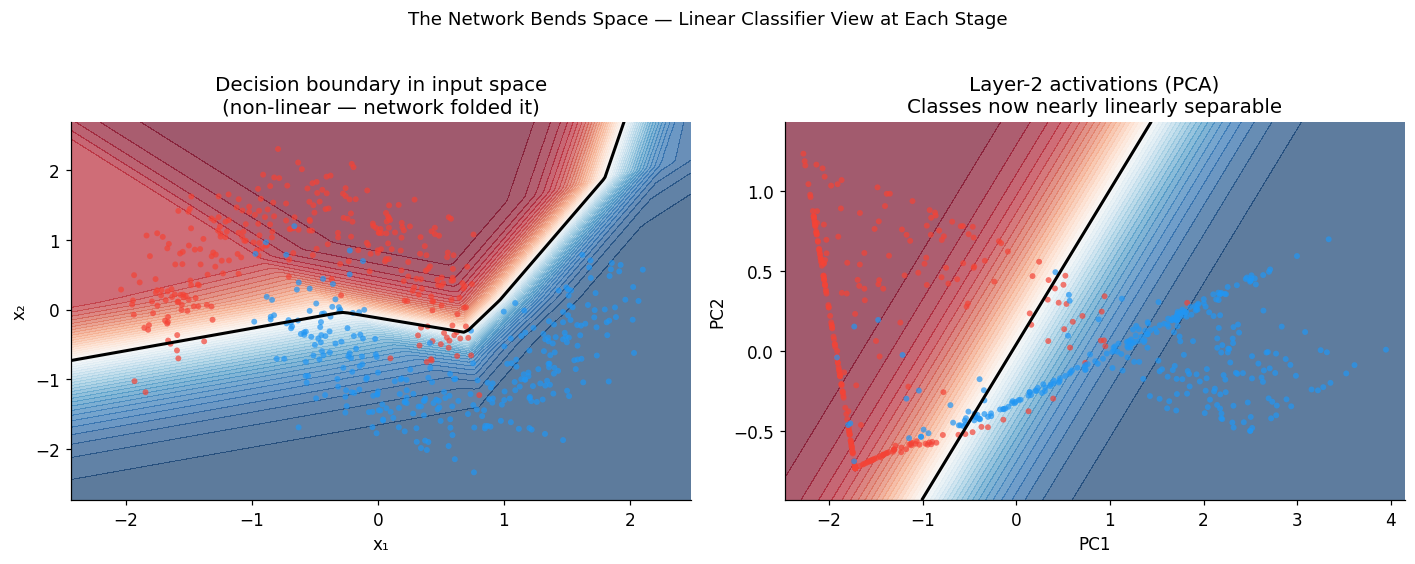

In [8]:
# ── Decision boundary in input space vs layer-2 activations ──────────────────
h = 0.04
g0_min, g0_max = X_vis[:, 0].min()-0.4, X_vis[:, 0].max()+0.4
g1_min, g1_max = X_vis[:, 1].min()-0.4, X_vis[:, 1].max()+0.4
gxx, gyy = np.meshgrid(np.arange(g0_min, g0_max, h),
                        np.arange(g1_min, g1_max, h))
X_grid  = np.c_[gxx.ravel(), gyy.ravel()]
Z_grid  = mnet.forward(X_grid).reshape(gxx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Input space decision boundary
ax = axes[0]
ax.contourf(gxx, gyy, Z_grid, levels=50, cmap='RdBu', alpha=0.65)
ax.contour(gxx, gyy, Z_grid, levels=[0.5], colors='k', linewidths=2)
ax.scatter(X_vis[y_vis==0, 0], X_vis[y_vis==0, 1],
           c=COLORS['neg'], s=15, alpha=0.7, edgecolors='none')
ax.scatter(X_vis[y_vis==1, 0], X_vis[y_vis==1, 1],
           c=COLORS['pos'], s=15, alpha=0.7, edgecolors='none')
ax.set_title('Decision boundary in input space\n(non-linear — network folded it)')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# Layer-2 activations (PCA projection)
ax = axes[1]
A2_vis = mnet.transforms(X_vis)['A2 (post-ReLU)']
proj   = pca_2d(A2_vis)

from sklearn.linear_model import LogisticRegression as SKLearnLR
sk_lr = SKLearnLR(max_iter=500)
sk_lr.fit(proj, y_vis)
p_min0, p_max0 = proj[:,0].min()-0.2, proj[:,0].max()+0.2
p_min1, p_max1 = proj[:,1].min()-0.2, proj[:,1].max()+0.2
pg0, pg1 = np.meshgrid(np.linspace(p_min0,p_max0,200),
                        np.linspace(p_min1,p_max1,200))
P_grid = sk_lr.predict_proba(np.c_[pg0.ravel(), pg1.ravel()])[:,1].reshape(pg0.shape)

ax.contourf(pg0, pg1, P_grid, levels=40, cmap='RdBu', alpha=0.65)
ax.contour(pg0,  pg1, P_grid, levels=[0.5], colors='k', linewidths=2)
ax.scatter(proj[y_vis==0, 0], proj[y_vis==0, 1],
           c=COLORS['neg'], s=15, alpha=0.7, edgecolors='none')
ax.scatter(proj[y_vis==1, 0], proj[y_vis==1, 1],
           c=COLORS['pos'], s=15, alpha=0.7, edgecolors='none')
ax.set_title('Layer-2 activations (PCA)\nClasses now nearly linearly separable')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('The Network Bends Space — Linear Classifier View at Each Stage',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 6 — Chain Rule & Backpropagation

### Why chain rule?

The loss $\mathcal{L}$ depends on $\hat{y}$, which depends on $z^{[3]}$,  
which depends on $\mathbf{W}^{[3]}$, and so on back to $\mathbf{W}^{[1]}$.  

To update $\mathbf{W}^{[1]}$ we must differentiate through *every layer*:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[1]}} =
  \frac{\partial \mathcal{L}}{\partial \hat{y}}
  \cdot \frac{\partial \hat{y}}{\partial z^{[3]}}
  \cdot \frac{\partial z^{[3]}}{\partial \mathbf{a}^{[2]}}
  \cdot \frac{\partial \mathbf{a}^{[2]}}{\partial \mathbf{z}^{[2]}}
  \cdot \frac{\partial \mathbf{z}^{[2]}}{\partial \mathbf{a}^{[1]}}
  \cdot \frac{\partial \mathbf{a}^{[1]}}{\partial \mathbf{z}^{[1]}}
  \cdot \frac{\partial \mathbf{z}^{[1]}}{\partial \mathbf{W}^{[1]}}$$

### Full derivation for our 2→3→2→1 network

**Step 1:** Loss gradient at output (BCE loss, sigmoid output):

$$\delta^{[3]} = \frac{\partial \mathcal{L}}{\partial z^{[3]}} = \hat{y} - y$$

*(A well-known simplification: the BCE loss derivative and sigmoid derivative cancel cleanly.)*

**Step 2:** Gradients for Layer 3:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[3]}} = \delta^{[3]} \cdot \mathbf{a}^{[2]\top},
\qquad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[3]}} = \delta^{[3]}$$

**Step 3:** Backpropagate to Layer 2:

$$\delta^{[2]} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{[2]}} =
  \left(\mathbf{W}^{[3]\top} \delta^{[3]}\right) \odot \text{ReLU}'(\mathbf{z}^{[2]})$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[2]}} = \delta^{[2]} \cdot \mathbf{a}^{[1]\top}$$

**Step 4:** Backpropagate to Layer 1:

$$\delta^{[1]} = \left(\mathbf{W}^{[2]\top} \delta^{[2]}\right) \odot \text{ReLU}'(\mathbf{z}^{[1]})$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[1]}} = \delta^{[1]} \cdot \mathbf{x}^\top$$

The $\odot$ symbol means **element-wise multiply** (Hadamard product).


In [9]:
def backprop(net, X, y):
    """
    Full backpropagation for ThreeLayerNet.
    Every gradient is derived from first principles above.
    Returns a dict of gradients.
    """
    # ── Forward pass (populates net.cache) ───────────────────────────────────
    y_hat = net.forward(X)                        # (N,)
    N     = len(y)
    c     = net.cache

    # ── Step 1: dL/dZ3 = ŷ − y  (BCE + sigmoid simplification) ──────────────
    # Derivation: dL/dA3 = -(y/ŷ - (1-y)/(1-ŷ)) / N
    #             dA3/dZ3 = σ(Z3)(1-σ(Z3))
    #             Product simplifies to (ŷ - y)/N
    dZ3 = (y_hat - y)[:, None] / N               # (N, 1)

    # ── Step 2: Layer 3 weight gradients ─────────────────────────────────────
    dW3 = dZ3.T @ c['A2']                        # (1, 2)
    db3 = dZ3.sum(axis=0)                        # (1,)

    # ── Step 3: Backpropagate through Layer 2 ────────────────────────────────
    # dA2 = dZ3 · W3  (chain through linear)
    dA2 = dZ3 @ net.W3                           # (N, 2)
    # Element-wise multiply by ReLU'(Z2)
    dZ2 = dA2 * relu_deriv(c['Z2'])             # (N, 2)  ← Hadamard product
    dW2 = dZ2.T @ c['A1']                       # (2, 3)
    db2 = dZ2.sum(axis=0)                        # (2,)

    # ── Step 4: Backpropagate through Layer 1 ────────────────────────────────
    dA1 = dZ2 @ net.W2                           # (N, 3)
    dZ1 = dA1 * relu_deriv(c['Z1'])             # (N, 3)
    dW1 = dZ1.T @ c['X']                        # (3, 2)
    db1 = dZ1.sum(axis=0)                        # (3,)

    return dict(dW3=dW3, db3=db3, dW2=dW2, db2=db2, dW1=dW1, db1=db1)


# ── Numerical gradient check — proves our math is correct ────────────────────
def numerical_grad(net, X, y, param_name, eps=1e-5):
    """Central difference approximation: (f(θ+ε) - f(θ-ε)) / 2ε"""
    param = getattr(net, param_name)
    grad  = np.zeros_like(param)
    it    = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        orig = param[idx]

        param[idx] = orig + eps
        y_hat_p = net.forward(X)
        loss_p  = -np.mean(y * np.log(y_hat_p + 1e-12) +
                           (1-y) * np.log(1 - y_hat_p + 1e-12))

        param[idx] = orig - eps
        y_hat_m = net.forward(X)
        loss_m  = -np.mean(y * np.log(y_hat_m + 1e-12) +
                           (1-y) * np.log(1 - y_hat_m + 1e-12))

        grad[idx] = (loss_p - loss_m) / (2 * eps)
        param[idx] = orig
        it.iternext()
    return grad


np.random.seed(SEED)
X_chk = X_vis[:20]
y_chk = y_vis[:20]

net_chk = ThreeLayerNet(n_in=2, h1=3, h2=2)
net_chk.forward(X_chk)
grads = backprop(net_chk, X_chk, y_chk)

print("=== Gradient Check: Analytical vs. Numerical ===")
print(f"{'Parameter':<10} {'Max abs error':>20} {'Status':>10}")
print("-" * 44)
for pname, gname in [('W1','dW1'),('W2','dW2'),('W3','dW3')]:
    num_g = numerical_grad(net_chk, X_chk, y_chk, pname)
    ana_g = grads[gname]
    err   = np.max(np.abs(num_g - ana_g))
    status = '✓ PASS' if err < 1e-5 else '✗ FAIL'
    print(f"  {pname:<8} {err:>20.2e} {status:>10}")
print()
print("Max error < 1e-5 confirms our chain-rule derivation is correct.")


=== Gradient Check: Analytical vs. Numerical ===
Parameter         Max abs error     Status
--------------------------------------------
  W1                   4.31e-12     ✓ PASS
  W2                   6.17e-12     ✓ PASS
  W3                   7.46e-12     ✓ PASS

Max error < 1e-5 confirms our chain-rule derivation is correct.


---
## Section 7 — Weight Initialisation: Why Zero-Init Kills Learning

### The symmetry problem

If all weights start at zero:
- Every neuron in a layer receives the **same input**
- Every neuron computes the **same output**
- Every neuron gets the **same gradient**
- Every neuron updates **identically**

The network collapses to a single effective neuron, no matter how wide it is.  
This is called the **symmetry problem**.

### Three initialisations compared

| Scheme | Formula | When to use |
|--------|---------|-------------|
| Zero | $W = 0$ | **Never** |
| Random (too large) | $W \sim \mathcal{N}(0, 1)$ | Vanishing/exploding gradient |
| Xavier/Glorot | $W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}+n_{out}}}\right)$ | Tanh/sigmoid |
| He | $W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$ | **ReLU** — our default |


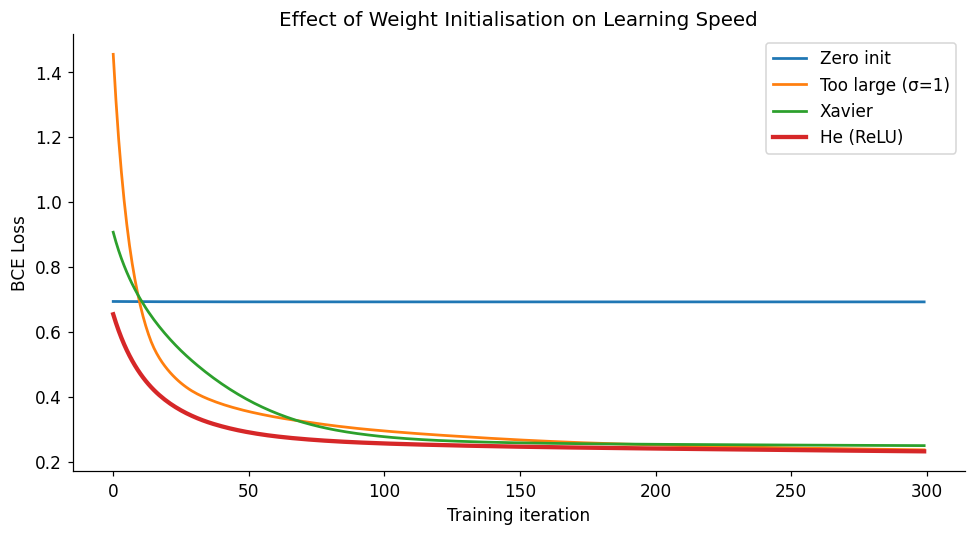

Zero init: loss barely moves — ALL neurons are identical (symmetry not broken).
Too large: initial loss is huge — saturated activations, tiny gradients.
He init:   fast, stable convergence — the right choice for ReLU networks.


In [10]:
np.random.seed(SEED)

# Minimal 2-layer net trained with each init
def train_with_init(W1_init, W2_init, X, y, lr=0.1, iters=300):
    W1, b1 = W1_init.copy(), np.zeros(W1_init.shape[0])
    W2, b2 = W2_init.copy(), np.zeros(1)
    losses = []
    for _ in range(iters):
        Z1 = X @ W1.T + b1; A1 = relu(Z1)
        Z2 = A1 @ W2.T + b2; A2 = sigmoid(Z2)
        yh = A2.squeeze()
        loss = -np.mean(y * np.log(yh+1e-12) + (1-y)*np.log(1-yh+1e-12))
        losses.append(loss)
        # Backward
        dZ2 = (yh - y)[:, None] / len(y)
        dW2 = dZ2.T @ A1; db2 = dZ2.sum(axis=0)
        dA1 = dZ2 @ W2; dZ1 = dA1 * relu_deriv(Z1)
        dW1 = dZ1.T @ X; db1 = dZ1.sum(axis=0)
        W2 -= lr*dW2; b2 -= lr*db2
        W1 -= lr*dW1; b1 -= lr*db1
    return losses


X_i, y_i = X_vis[:200], y_vis[:200]
n_in, n_h = 2, 8

inits = {
    'Zero init': (np.zeros((n_h, n_in)), np.zeros((1, n_h))),
    'Too large (σ=1)': (np.random.randn(n_h, n_in), np.random.randn(1, n_h)),
    'Xavier': (np.random.randn(n_h, n_in) * np.sqrt(2/(n_in+n_h)),
               np.random.randn(1, n_h)    * np.sqrt(2/(n_h+1))),
    'He (ReLU)': (np.random.randn(n_h, n_in) * np.sqrt(2/n_in),
                  np.random.randn(1, n_h)    * np.sqrt(2/n_h)),
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, (W1_i, W2_i) in inits.items():
    losses = train_with_init(W1_i, W2_i, X_i, y_i)
    lw = 2.8 if 'He' in label else 1.8
    ax.plot(losses, label=label, lw=lw)

ax.set_xlabel('Training iteration'); ax.set_ylabel('BCE Loss')
ax.set_title('Effect of Weight Initialisation on Learning Speed')
ax.legend()
plt.tight_layout()
plt.show()

print("Zero init: loss barely moves — ALL neurons are identical (symmetry not broken).")
print("Too large: initial loss is huge — saturated activations, tiny gradients.")
print("He init:   fast, stable convergence — the right choice for ReLU networks.")


---
## Section 8 — Computation Graphs: Tracing the Forward Pass

Before we build autodiff, we need to see *what* autodiff is automating.

A **computation graph** records every elementary operation with its  
inputs and outputs. Each node stores enough information to compute  
a local gradient during the backward pass.

We'll trace a single forward pass through our 2-layer network and  
print every intermediate value explicitly.


In [11]:
def trace_forward(x, w1, b1, w2, b2, w3, b3, y_true):
    """
    Explicit step-by-step forward pass.
    Every variable is named and printed so there are no hidden steps.
    x: shape (2,)
    """
    print("=" * 60)
    print("COMPUTATION GRAPH — FORWARD PASS TRACE")
    print("=" * 60)
    print(f"  INPUT  x  = {x}")
    print()

    # Layer 1
    z1 = w1 @ x + b1
    a1 = relu(z1)
    print(f"[Layer 1 — Linear]")
    print(f"  z1 = W1 · x + b1")
    print(f"     = {np.round(w1, 3)} · {x} + {np.round(b1, 3)}")
    print(f"     = {np.round(z1, 4)}")
    print(f"  a1 = ReLU(z1) = {np.round(a1, 4)}")
    print()

    # Layer 2
    z2 = w2 @ a1 + b2
    a2 = relu(z2)
    print(f"[Layer 2 — Linear]")
    print(f"  z2 = W2 · a1 + b2 = {np.round(z2, 4)}")
    print(f"  a2 = ReLU(z2)     = {np.round(a2, 4)}")
    print()

    # Layer 3 (output)
    z3 = w3 @ a2 + b3
    y_hat = sigmoid(z3)[0]
    print(f"[Layer 3 — Output]")
    print(f"  z3   = W3 · a2 + b3 = {np.round(z3, 4)}")
    print(f"  ŷ    = σ(z3)        = {y_hat:.6f}")
    print()

    # Loss
    eps = 1e-12
    loss = -(y_true * np.log(y_hat + eps) + (1 - y_true) * np.log(1 - y_hat + eps))
    print(f"[Loss — BCE]")
    print(f"  y_true = {y_true}")
    print(f"  L = −[y·log(ŷ) + (1−y)·log(1−ŷ)]")
    print(f"    = −[{y_true}·log({y_hat:.4f}) + {1-y_true}·log({1-y_hat:.4f})]")
    print(f"    = {loss:.6f}")
    print()

    # Backward pass (chain rule, scalar case)
    dL_dz3 = y_hat - y_true
    print(f"[Backward — dL/dz3 = ŷ − y = {dL_dz3:.6f}]")
    dL_dW3 = dL_dz3 * a2
    print(f"  dL/dW3 = dL/dz3 · a2 = {np.round(dL_dW3, 6)}")

    dL_da2 = dL_dz3 * w3
    dL_dz2 = dL_da2 * (z2 > 0).astype(float)
    print(f"  dL/dz2 = (W3ᵀ·dL/dz3) ⊙ ReLU'(z2) = {np.round(dL_dz2, 6)}")

    dL_dW2 = np.outer(dL_dz2, a1)
    print(f"  dL/dW2 = dL/dz2 ⊗ a1 (outer product), shape {dL_dW2.shape}")

    dL_da1 = w2.T @ dL_dz2
    dL_dz1 = dL_da1 * (z1 > 0).astype(float)
    print(f"  dL/dz1 = (W2ᵀ·dL/dz2) ⊙ ReLU'(z1) = {np.round(dL_dz1, 6)}")

    dL_dW1 = np.outer(dL_dz1, x)
    print(f"  dL/dW1 = dL/dz1 ⊗ x (outer product), shape {dL_dW1.shape}")
    print("=" * 60)

    return loss, dL_dW1, dL_dW2, dL_dW3


# Run on one training sample
np.random.seed(SEED)
net_t = ThreeLayerNet()
x_one = X_vis[0]
y_one = y_vis[0]
_ = trace_forward(x_one, net_t.W1, net_t.b1, net_t.W2, net_t.b2,
                  net_t.W3.squeeze(), net_t.b3, y_one)


COMPUTATION GRAPH — FORWARD PASS TRACE
  INPUT  x  = [0.06515198 1.38812736]

[Layer 1 — Linear]
  z1 = W1 · x + b1
     = [[ 0.497 -0.138]
 [ 0.648  1.523]
 [-0.234 -0.234]] · [0.06515198 1.38812736] + [0. 0. 0.]
     = [-0.1596  2.1564 -0.3403]
  a1 = ReLU(z1) = [0.     2.1564 0.    ]

[Layer 2 — Linear]
  z2 = W2 · a1 + b2 = [-0.2434 -0.4123]
  a2 = ReLU(z2)     = [0. 0.]

[Layer 3 — Output]
  z3   = W3 · a2 + b3 = [0.]
  ŷ    = σ(z3)        = 0.500000

[Loss — BCE]
  y_true = 0
  L = −[y·log(ŷ) + (1−y)·log(1−ŷ)]
    = −[0·log(0.5000) + 1·log(0.5000)]
    = 0.693147

[Backward — dL/dz3 = ŷ − y = 0.500000]
  dL/dW3 = dL/dz3 · a2 = [0. 0.]
  dL/dz2 = (W3ᵀ·dL/dz3) ⊙ ReLU'(z2) = [ 0. -0.]
  dL/dW2 = dL/dz2 ⊗ a1 (outer product), shape (2, 3)
  dL/dz1 = (W2ᵀ·dL/dz2) ⊙ ReLU'(z1) = [0. 0. 0.]
  dL/dW1 = dL/dz1 ⊗ x (outer product), shape (3, 2)


---
## Section 9 — Gradient Vanishing: The Cost of Stacking Sigmoids

### Why does it happen?

The sigmoid derivative is always $\leq 0.25$.

At each layer, backprop multiplies by this derivative.  
With $L$ sigmoid layers, the gradient at layer 1 is bounded by:

$$\left|\frac{\partial \mathcal{L}}{\partial \mathbf{z}^{[1]}}\right|
\leq 0.25^L \cdot \left|\frac{\partial \mathcal{L}}{\partial z^{[L]}}\right|$$

| Layers | Max gradient scale |
|--------|--------------------|
| 1 | $0.25$ |
| 2 | $0.0625$ |
| 5 | $\approx 10^{-3}$ |
| 10 | $\approx 10^{-6}$ |

**ReLU breaks the chain:** $\text{ReLU}'(z) = 1$ for $z > 0$.  
Gradients flow unchanged through active units — no shrinkage.


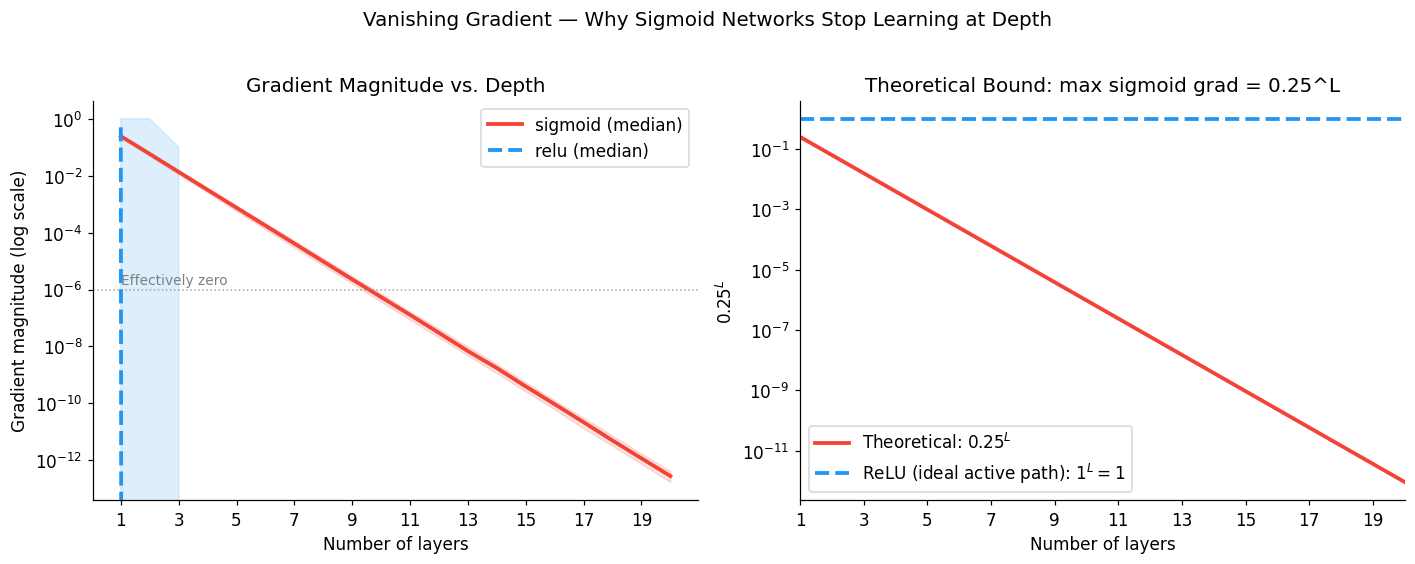

With 10 sigmoid layers, the gradient at layer 1 is ~10⁻⁶ of the output gradient.
The weights at layer 1 receive essentially zero update signal.
This is why deep networks use ReLU (or variants) as default activations.


In [12]:
# Simulate gradient magnitude through N sigmoid vs ReLU layers
def gradient_through_n_layers(activation, n_layers=15, n_trials=200):
    """
    Propagate a gradient of magnitude 1 backward through n_layers.
    For each trial, draw random pre-activations and multiply by local derivatives.
    """
    np.random.seed(SEED)
    grad_mags = []
    for _ in range(n_trials):
        grad = 1.0
        for _ in range(n_layers):
            # Random pre-activation typical of a network mid-training
            z = np.random.randn() * 0.5
            if activation == 'sigmoid':
                local_deriv = sigmoid_deriv(z)
            else:  # relu
                local_deriv = float(z > 0)  # 0 or 1
            grad *= local_deriv
        grad_mags.append(abs(grad))
    return np.array(grad_mags)


max_layers = 20
layer_counts = np.arange(1, max_layers + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for act, color, ls in [('sigmoid', COLORS['neg'], '-'),
                        ('relu',    COLORS['pos'], '--')]:
    means, p25s, p75s = [], [], []
    for L in layer_counts:
        mags = gradient_through_n_layers(act, n_layers=L)
        means.append(np.median(mags))
        p25s.append(np.percentile(mags, 10))
        p75s.append(np.percentile(mags, 90))

    axes[0].semilogy(layer_counts, means, color=color, lw=2.5, ls=ls,
                     label=f'{act} (median)')
    axes[0].fill_between(layer_counts, p25s, p75s, color=color, alpha=0.15)

axes[0].set_xlabel('Number of layers'); axes[0].set_ylabel('Gradient magnitude (log scale)')
axes[0].set_title('Gradient Magnitude vs. Depth')
axes[0].legend()
axes[0].axhline(1e-6, color='gray', ls=':', lw=1, alpha=0.7)
axes[0].text(1, 1.5e-6, 'Effectively zero', fontsize=9, color='gray')

# Show 0.25^L curve explicitly
L_range = np.linspace(1, max_layers, 200)
axes[1].semilogy(L_range, 0.25**L_range, color=COLORS['neg'], lw=2.5,
                 label=r'Theoretical: $0.25^L$')
axes[1].semilogy(L_range, np.ones_like(L_range), color=COLORS['pos'], lw=2.5,
                 ls='--', label='ReLU (ideal active path): $1^L = 1$')
axes[1].set_xlabel('Number of layers'); axes[1].set_ylabel(r'$0.25^L$')
axes[1].set_title("Theoretical Bound: max sigmoid grad = 0.25^L")
axes[1].legend()
axes[1].set_xlim(1, max_layers)

for ax in axes:
    ax.set_xticks(range(1, max_layers+1, 2))

plt.suptitle('Vanishing Gradient — Why Sigmoid Networks Stop Learning at Depth',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("With 10 sigmoid layers, the gradient at layer 1 is ~10⁻⁶ of the output gradient.")
print("The weights at layer 1 receive essentially zero update signal.")
print("This is why deep networks use ReLU (or variants) as default activations.")


---
## Section 10 — Loss Functions: BCE vs. MSE

We derive and compare two loss functions applied to the *same* network.

### Binary Cross-Entropy (BCE)

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i}\left[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

**Gradient:** $\dfrac{\partial \mathcal{L}_{BCE}}{\partial z^{[L]}} = \hat{y} - y$

### Mean Squared Error (MSE)

$$\mathcal{L}_{MSE} = \frac{1}{N}\sum_{i}(\hat{y}_i - y_i)^2$$

**Gradient:** $\dfrac{\partial \mathcal{L}_{MSE}}{\partial z^{[L]}} = \frac{2}{N}(\hat{y}_i - y_i) \cdot \hat{y}_i(1-\hat{y}_i)$

Note the extra $\hat{y}(1-\hat{y})$ term — the sigmoid derivative.  
When $\hat{y} \approx 0$ or $\hat{y} \approx 1$ (confident predictions), this term  
approaches zero → **MSE suffers from gradient saturation at confident predictions**.  
BCE does not have this problem.


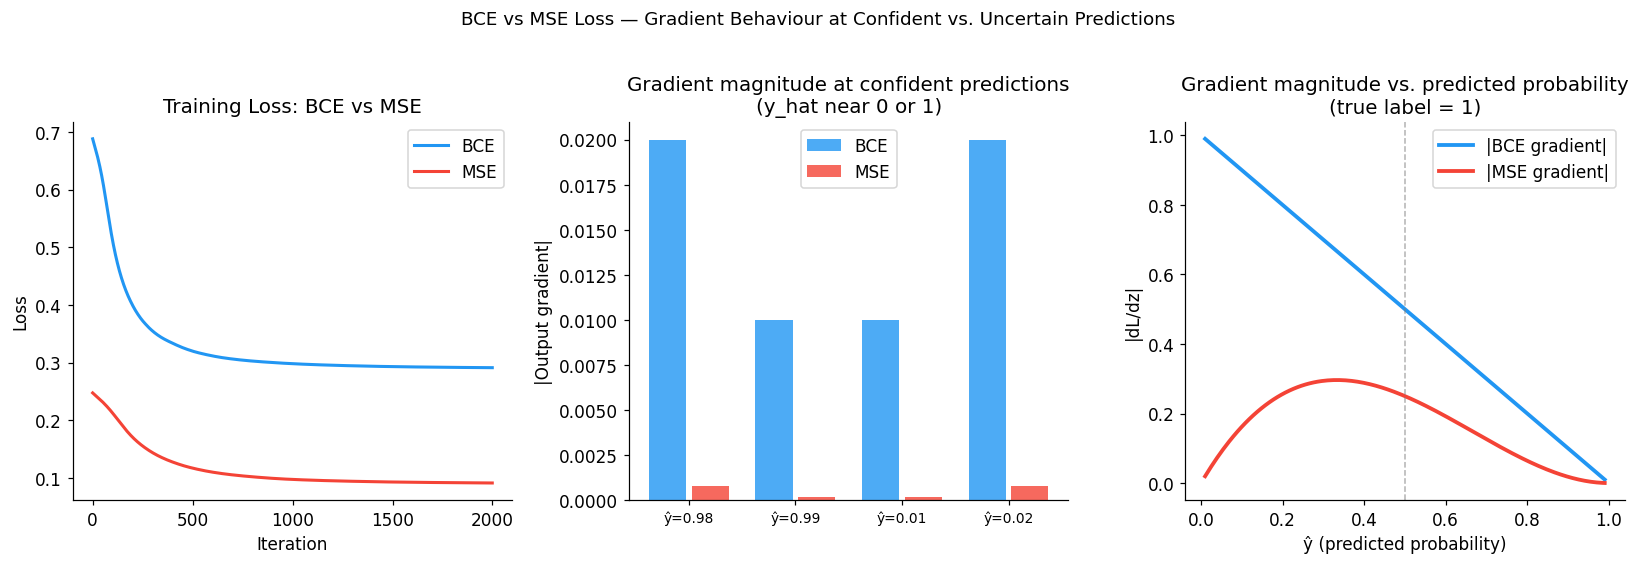

Key insight: At ŷ ≈ 0.98 (confident correct prediction):
  BCE gradient ≈ 0.0200  (still informative when wrong)
  MSE gradient ≈ 0.000784  (near zero — saturated)

MSE saturates near confident predictions for classification.
BCE maintains informative gradients across the full range.
→ Use BCE for classification. MSE is for regression.


In [13]:
class ThreeLayerNetLoss(ThreeLayerNet):
    """Extends ThreeLayerNet with two loss functions and their backward passes."""

    def bce_loss(self, y_hat, y):
        eps = 1e-12
        return -np.mean(y * np.log(y_hat + eps) + (1-y) * np.log(1 - y_hat + eps))

    def mse_loss(self, y_hat, y):
        return np.mean((y_hat - y)**2)

    def backward_bce(self, y):
        """dL/dZ3 = (ŷ - y) / N  [BCE + sigmoid simplification]"""
        N = len(y)
        c = self.cache
        y_hat = c['A3'].squeeze()
        dZ3 = (y_hat - y)[:, None] / N
        return self._backward_from_dZ3(dZ3)

    def backward_mse(self, y):
        """dL/dZ3 = 2(ŷ-y)/N * σ'(Z3)  [MSE, no simplification]"""
        N = len(y)
        c = self.cache
        y_hat = c['A3'].squeeze()
        # dL/dA3 = 2(ŷ-y)/N
        dA3 = 2 * (y_hat - y)[:, None] / N
        # dA3/dZ3 = sigmoid_deriv(Z3)
        dZ3 = dA3 * sigmoid_deriv(c['Z3'])
        return self._backward_from_dZ3(dZ3)

    def _backward_from_dZ3(self, dZ3):
        c = self.cache
        dW3 = dZ3.T @ c['A2'];        db3 = dZ3.sum(axis=0)
        dA2 = dZ3 @ self.W3
        dZ2 = dA2 * relu_deriv(c['Z2'])
        dW2 = dZ2.T @ c['A1'];        db2 = dZ2.sum(axis=0)
        dA1 = dZ2 @ self.W2
        dZ1 = dA1 * relu_deriv(c['Z1'])
        dW1 = dZ1.T @ c['X'];         db1 = dZ1.sum(axis=0)
        return dict(dW3=dW3, db3=db3, dW2=dW2, db2=db2, dW1=dW1, db1=db1)

    def train(self, X, y, loss_fn='bce', lr=0.05, iters=2000):
        losses = []
        for _ in range(iters):
            y_hat = self.forward(X)
            if loss_fn == 'bce':
                loss  = self.bce_loss(y_hat, y)
                grads = self.backward_bce(y)
            else:
                loss  = self.mse_loss(y_hat, y)
                grads = self.backward_mse(y)
            losses.append(loss)
            for p, g in [('W1','dW1'),('b1','db1'),('W2','dW2'),
                          ('b2','db2'),('W3','dW3'),('b3','db3')]:
                setattr(self, p, getattr(self, p) - lr * grads[g])
        return losses


# ── Train same architecture with BCE and MSE ─────────────────────────────────
np.random.seed(SEED); net_bce = ThreeLayerNetLoss()
np.random.seed(SEED); net_mse = ThreeLayerNetLoss()

losses_bce = net_bce.train(X_vis, y_vis, loss_fn='bce', lr=0.05, iters=2000)
losses_mse = net_mse.train(X_vis, y_vis, loss_fn='mse', lr=0.05, iters=2000)

# ── Compare gradients at confident vs uncertain predictions ──────────────────
y_confident   = np.array([0.98, 0.99, 0.01, 0.02])
y_uncertain   = np.array([0.55, 0.52, 0.48, 0.45])
y_true_conf   = np.array([1., 1., 0., 0.])

def bce_grad_out(y_hat, y): return y_hat - y
def mse_grad_out(y_hat, y):
    return 2*(y_hat - y) * sigmoid_deriv(np.log(y_hat/(1-y_hat+1e-12)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loss curves
axes[0].plot(losses_bce, color=COLORS['pos'], lw=2, label='BCE')
axes[0].plot(losses_mse, color=COLORS['neg'], lw=2, label='MSE')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss: BCE vs MSE')
axes[0].legend()

# Gradient comparison — confident predictions
bce_conf = np.abs(bce_grad_out(y_confident, y_true_conf))
mse_conf = np.abs(mse_grad_out(y_confident, y_true_conf))
x_ticks  = [f'ŷ={v}' for v in y_confident]
x_pos    = np.arange(len(y_confident))
axes[1].bar(x_pos - 0.2, bce_conf, 0.35, label='BCE', color=COLORS['pos'], alpha=0.8)
axes[1].bar(x_pos + 0.2, mse_conf, 0.35, label='MSE', color=COLORS['neg'], alpha=0.8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(x_ticks, fontsize=9)
axes[1].set_ylabel('|Output gradient|')
axes[1].set_title('Gradient magnitude at confident predictions\n(y_hat near 0 or 1)')
axes[1].legend()

# Theoretical BCE vs MSE gradient as function of y_hat
yh_range = np.linspace(0.01, 0.99, 200)
y_fixed  = np.ones_like(yh_range)  # true label = 1
bce_g = np.abs(bce_grad_out(yh_range, y_fixed))
mse_g = np.abs(mse_grad_out(yh_range, y_fixed))
axes[2].plot(yh_range, bce_g, color=COLORS['pos'], lw=2.5, label='|BCE gradient|')
axes[2].plot(yh_range, mse_g, color=COLORS['neg'], lw=2.5, label='|MSE gradient|')
axes[2].axvline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
axes[2].set_xlabel('ŷ (predicted probability)')
axes[2].set_ylabel('|dL/dz|')
axes[2].set_title('Gradient magnitude vs. predicted probability\n(true label = 1)')
axes[2].legend()

plt.suptitle('BCE vs MSE Loss — Gradient Behaviour at Confident vs. Uncertain Predictions',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: At ŷ ≈ 0.98 (confident correct prediction):")
print(f"  BCE gradient ≈ {bce_conf[0]:.4f}  (still informative when wrong)")
print(f"  MSE gradient ≈ {mse_conf[0]:.6f}  (near zero — saturated)")
print()
print("MSE saturates near confident predictions for classification.")
print("BCE maintains informative gradients across the full range.")
print("→ Use BCE for classification. MSE is for regression.")


---
## Section 11 — Autodiff from Scratch: A Minimal Reverse-Mode Engine

### What PyTorch's autograd actually does

When you call `loss.backward()` in PyTorch, it:
1. Walks the computation graph **in reverse** (topological order)
2. At each node, multiplies the incoming gradient by the local derivative
3. Accumulates gradients into `.grad`

We'll build a minimal version of this in ~80 lines of pure Python.

### The `Value` class

Each `Value` wraps a scalar, stores its `_backward` closure,  
and keeps references to its parents (`_prev`). Calling `.backward()`  
on the output triggers a topological traversal of the graph.


In [14]:
class Value:
    """
    Minimal scalar-valued autograd engine.
    Inspired by Andrej Karpathy's micrograd — reimplemented from first principles.
    Supports: +, -, *, /, **, exp, log, relu, sigmoid, tanh.
    """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data     = float(data)
        self.grad     = 0.0          # dL/d(self), accumulated
        self._backward = lambda: None
        self._prev    = set(_children)
        self._op      = _op
        self.label    = label

    # ── Arithmetic ────────────────────────────────────────────────────────────
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += out.grad      # dL/dself = dL/dout * 1
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad   # product rule
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, exponent):
        assert isinstance(exponent, (int, float))
        out = Value(self.data ** exponent, (self,), f'**{exponent}')
        def _backward():
            self.grad += (exponent * self.data**(exponent - 1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):     return self * -1
    def __sub__(self, o):  return self + (-o if isinstance(o, Value) else Value(-o))
    def __truediv__(self, other):
        return self * (other if isinstance(other, Value) else Value(other))**-1
    def __radd__(self, o): return self + o
    def __rmul__(self, o): return self * o
    def __rsub__(self, o): return Value(o) + (-self)
    def __rtruediv__(self, o): return Value(o) / self

    # ── Activations ──────────────────────────────────────────────────────────
    def exp(self):
        e = np.exp(self.data)
        out = Value(e, (self,), 'exp')
        def _backward():
            self.grad += e * out.grad
        out._backward = _backward
        return out

    def log(self):
        assert self.data > 0, "log of non-positive value"
        out = Value(np.log(self.data), (self,), 'log')
        def _backward():
            self.grad += (1 / self.data) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        s   = 1 / (1 + np.exp(-self.data))
        out = Value(s, (self,), 'σ')
        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t   = np.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    # ── Backward ──────────────────────────────────────────────────────────────
    def backward(self):
        """Reverse-mode autodiff via topological sort."""
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0                # dL/dL = 1
        for node in reversed(topo):   # walk graph backwards
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"


# ── Demo 1: simple expression ─────────────────────────────────────────────────
print("=== Demo 1: z = (x + y) * w, L = z² ===")
x = Value(2.0, label='x')
y = Value(3.0, label='y')
w = Value(-1.5, label='w')

z = (x + y) * w
L = z**2
L.backward()

print(f"  x={x.data}, y={y.data}, w={w.data}")
print(f"  z = (x+y)*w = {z.data:.4f}")
print(f"  L = z²      = {L.data:.4f}")
print(f"  dL/dx = {x.grad:.4f}  (expected: 2z*w = {2*z.data*w.data:.4f})")
print(f"  dL/dy = {y.grad:.4f}  (same as dL/dx, x and y enter symmetrically)")
print(f"  dL/dw = {w.grad:.4f}  (expected: 2z*(x+y) = {2*z.data*(x.data+y.data):.4f})")


=== Demo 1: z = (x + y) * w, L = z² ===
  x=2.0, y=3.0, w=-1.5
  z = (x+y)*w = -7.5000
  L = z²      = 56.2500
  dL/dx = 22.5000  (expected: 2z*w = 22.5000)
  dL/dy = 22.5000  (same as dL/dx, x and y enter symmetrically)
  dL/dw = -75.0000  (expected: 2z*(x+y) = -75.0000)


In [15]:
# ── Demo 2: forward pass through a 2→2→1 network using Value ─────────────────
print("=== Demo 2: Small network forward + backward ===")
print()

# Inputs
x1 = Value(1.0, label='x1')
x2 = Value(-0.5, label='x2')

# Layer 1 weights (2 neurons, 2 inputs each)
w11 = Value( 0.4, label='w11');  w12 = Value(-0.3, label='w12');  b1a = Value(0.1, label='b1a')
w21 = Value(-0.2, label='w21');  w22 = Value( 0.5, label='w22');  b1b = Value(0.0, label='b1b')

# Layer 1 forward
z1a = w11*x1 + w12*x2 + b1a;   a1a = z1a.relu()
z1b = w21*x1 + w22*x2 + b1b;   a1b = z1b.relu()

# Layer 2 weights (1 neuron, 2 inputs)
w31 = Value(0.6, label='w31');  w32 = Value(-0.4, label='w32');  b2 = Value(0.05, label='b2')

# Layer 2 forward
z2  = w31*a1a + w32*a1b + b2
y_pred = z2.sigmoid()

# Loss: BCE for y_true = 1
y_true = 1.0
eps    = 1e-7
loss   = -(Value(y_true) * y_pred.log() + Value(1 - y_true) * (Value(1.0) - y_pred).log())

print(f"  x1={x1.data}, x2={x2.data}")
print(f"  Layer 1 → z1a={z1a.data:.4f}, a1a=ReLU={a1a.data:.4f}")
print(f"            z1b={z1b.data:.4f}, a1b=ReLU={a1b.data:.4f}")
print(f"  Layer 2 → z2={z2.data:.4f}, ŷ=σ(z2)={y_pred.data:.4f}")
print(f"  Loss (BCE, y=1) = {loss.data:.6f}")
print()

# Backward
loss.backward()

print("  Gradients (dL/dw):")
for name, val in [('w11', w11), ('w12', w12), ('w21', w21), ('w22', w22),
                   ('w31', w31), ('w32', w32)]:
    print(f"    dL/d{name} = {val.grad:.6f}")


=== Demo 2: Small network forward + backward ===

  x1=1.0, x2=-0.5
  Layer 1 → z1a=0.6500, a1a=ReLU=0.6500
            z1b=-0.4500, a1b=ReLU=0.0000
  Layer 2 → z2=0.4400, ŷ=σ(z2)=0.6083
  Loss (BCE, y=1) = 0.497154

  Gradients (dL/dw):
    dL/dw11 = -0.235045
    dL/dw12 = 0.117522
    dL/dw21 = 0.000000
    dL/dw22 = 0.000000
    dL/dw31 = -0.254632
    dL/dw32 = 0.000000


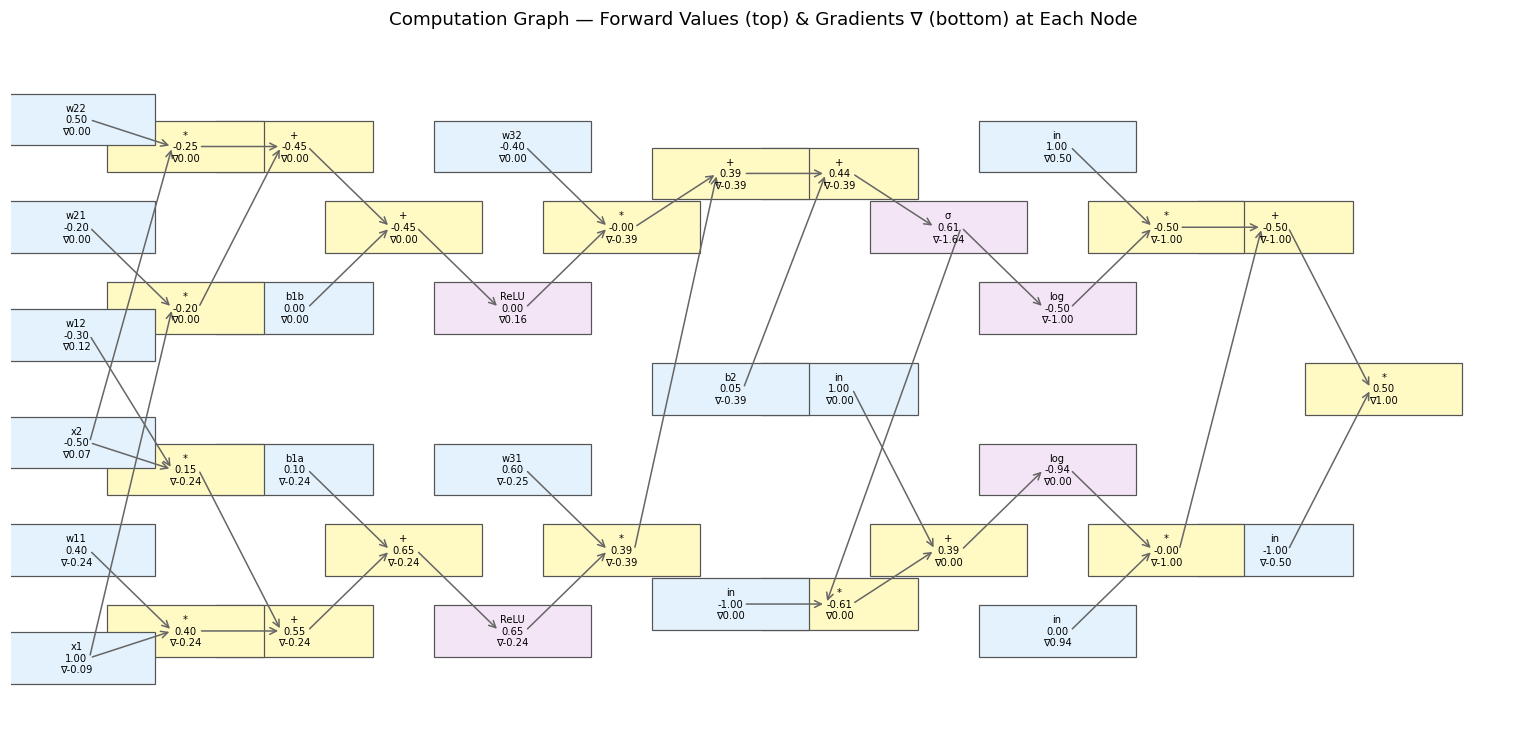

Every node shows: [label / op]  [forward value]  [∇ accumulated gradient]
The backward pass walked this graph in reverse to fill in the gradient values.


In [16]:
# ── Visualise the computation graph ───────────────────────────────────────────
def draw_computation_graph(root, ax, max_nodes=60):
    """Draw a simplified computation graph using matplotlib arrows."""
    # BFS to collect all nodes
    from collections import deque
    nodes, edges = [], []
    visited = set()
    queue = deque([root])
    while queue and len(nodes) < max_nodes:
        node = queue.popleft()
        if id(node) in visited: continue
        visited.add(id(node))
        nodes.append(node)
        for child in node._prev:
            edges.append((child, node))
            queue.append(child)

    # Simple layered layout via BFS depth
    depth = {}
    queue = deque([(root, 0)])
    seen  = set()
    while queue:
        n, d = queue.popleft()
        if id(n) in seen: continue
        seen.add(id(n)); depth[id(n)] = d
        for c in n._prev: queue.append((c, d+1))

    max_d = max(depth.values()) if depth else 1
    layer_nodes = {}
    for n in nodes:
        d = depth.get(id(n), 0)
        layer_nodes.setdefault(d, []).append(n)

    pos = {}
    for d, ns in layer_nodes.items():
        for i, n in enumerate(ns):
            x_pos = (max_d - d) / max(max_d, 1)
            y_pos = (i + 0.5) / len(ns)
            pos[id(n)] = (x_pos, y_pos)

    ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.05)

    # Edges
    for (src, dst) in edges:
        if id(src) in pos and id(dst) in pos:
            sx, sy = pos[id(src)]
            dx, dy = pos[id(dst)]
            ax.annotate('', xy=(dx-0.01, dy), xytext=(sx+0.01, sy),
                        arrowprops=dict(arrowstyle='->', color='#666', lw=1))

    # Nodes
    for n in nodes:
        if id(n) not in pos: continue
        nx, ny = pos[id(n)]
        op  = n._op or 'in'
        col = '#E3F2FD' if op == 'in' else '#FFF9C4' if op in ('+','*','**-1') else '#F3E5F5'
        rect = plt.Rectangle((nx-0.06, ny-0.04), 0.12, 0.08,
                               facecolor=col, edgecolor='#555', lw=0.8)
        ax.add_patch(rect)
        label_txt = f"{n.label or op}\n{n.data:.2f}\n∇{n.grad:.2f}"
        ax.text(nx, ny, label_txt, ha='center', va='center', fontsize=6.5)

    ax.axis('off')


fig, ax = plt.subplots(figsize=(14, 7))
draw_computation_graph(loss, ax, max_nodes=50)
ax.set_title('Computation Graph — Forward Values (top) & Gradients ∇ (bottom) at Each Node',
             fontsize=12)
plt.tight_layout()
plt.show()
print("Every node shows: [label / op]  [forward value]  [∇ accumulated gradient]")
print("The backward pass walked this graph in reverse to fill in the gradient values.")


---
## Section 12 — Loss Landscape: What SGD is Navigating

We freeze all but two weights and plot the loss surface  
as we vary those two parameters. This gives us the 2D contour  
that SGD must descend.

Real loss surfaces are high-dimensional, but 2D slices reveal:
- **Valleys** — fast descent directions
- **Saddle points** — areas where gradient is zero but not a minimum
- **Ridges** — directions that cause loss to increase


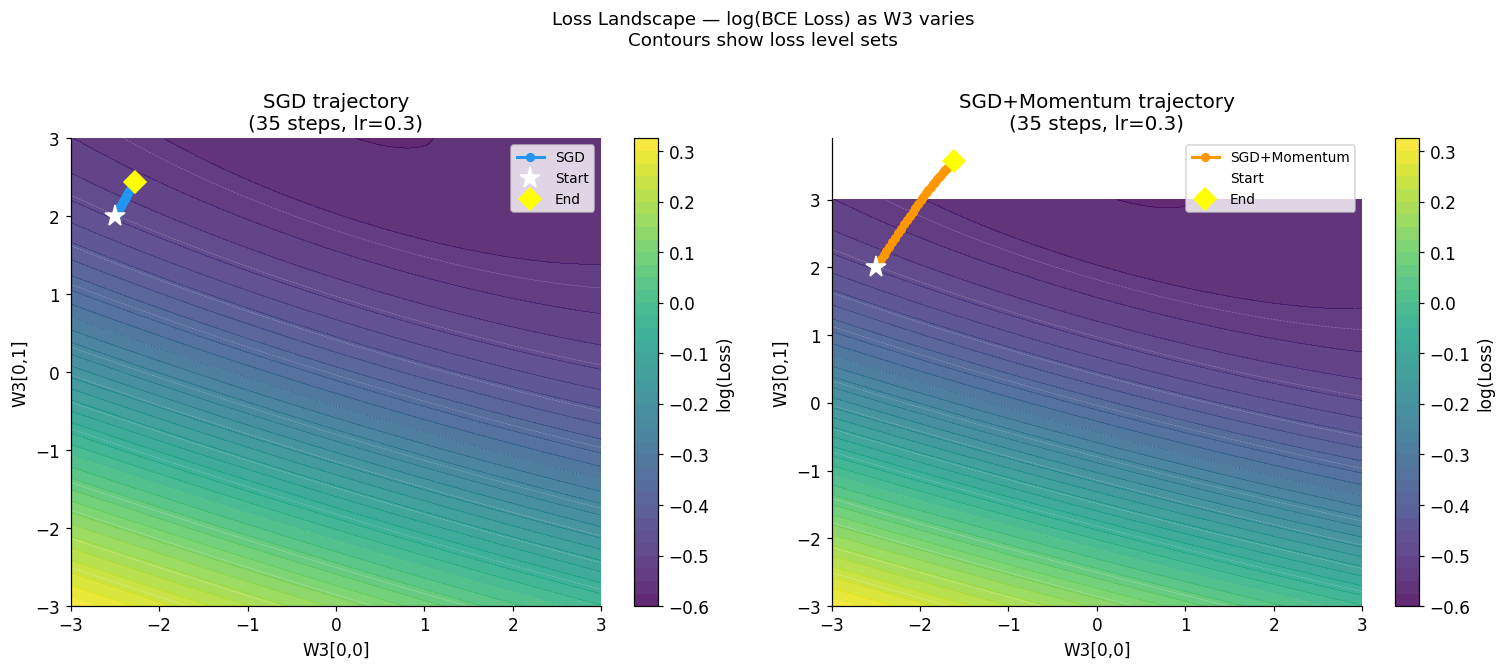

In [17]:
# Fix a small network and vary W3[0,0] and W3[0,1] to see the 2D loss surface
np.random.seed(SEED)
net_ls = ThreeLayerNet()

X_ls = X_vis[:150]; y_ls = y_vis[:150]

def compute_loss(w3_0, w3_1, net, X, y):
    """Compute BCE loss with W3[0,0]=w3_0, W3[0,1]=w3_1."""
    orig0, orig1 = net.W3[0, 0], net.W3[0, 1]
    net.W3[0, 0] = w3_0
    net.W3[0, 1] = w3_1
    y_hat = net.forward(X)
    loss  = -np.mean(y * np.log(y_hat + 1e-12) + (1-y) * np.log(1-y_hat + 1e-12))
    net.W3[0, 0] = orig0
    net.W3[0, 1] = orig1
    return loss

# Grid
w_range = np.linspace(-3, 3, 80)
W0_grid, W1_grid = np.meshgrid(w_range, w_range)
Loss_grid = np.vectorize(lambda a, b: compute_loss(a, b, net_ls, X_ls, y_ls))(
                W0_grid, W1_grid)

# SGD trajectory
def sgd_trajectory(net, X, y, lr=0.3, iters=40):
    w0s, w1s = [net.W3[0,0]], [net.W3[0,1]]
    for _ in range(iters):
        y_hat = net.forward(X)
        N = len(y)
        dZ3 = (y_hat - y)[:, None] / N
        c   = net.cache
        dW3 = dZ3.T @ c['A2']
        net.W3 -= lr * dW3
        w0s.append(net.W3[0,0]); w1s.append(net.W3[0,1])
    return w0s, w1s

# Reset to a starting point in a visible region
np.random.seed(SEED + 1)
net_ls.W3 = np.array([[-2.5, 2.0]])
w0_sgd, w1_sgd = sgd_trajectory(net_ls, X_ls, y_ls, lr=0.3, iters=35)

# Momentum trajectory
np.random.seed(SEED + 1)
net_ls2 = ThreeLayerNet()
net_ls2.W3 = np.array([[-2.5, 2.0]])
v = np.zeros_like(net_ls2.W3)

def momentum_trajectory(net, X, y, lr=0.3, momentum=0.85, iters=35):
    v = np.zeros_like(net.W3)
    w0s, w1s = [net.W3[0,0]], [net.W3[0,1]]
    for _ in range(iters):
        y_hat = net.forward(X)
        N = len(y)
        dZ3 = (y_hat - y)[:, None] / N
        c   = net.cache
        dW3 = dZ3.T @ c['A2']
        v    = momentum * v - lr * dW3
        net.W3 += v
        w0s.append(net.W3[0,0]); w1s.append(net.W3[0,1])
    return w0s, w1s

np.random.seed(SEED + 1)
net_ls2 = ThreeLayerNet(); net_ls2.W3 = np.array([[-2.5, 2.0]])
w0_mom, w1_mom = momentum_trajectory(net_ls2, X_ls, y_ls, lr=0.3, momentum=0.85)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, w0t, w1t, label, color in [
    (axes[0], w0_sgd, w1_sgd, 'SGD',           COLORS['pos']),
    (axes[1], w0_mom, w1_mom, 'SGD+Momentum',  COLORS['accent']),
]:
    cf = ax.contourf(W0_grid, W1_grid, np.log(Loss_grid + 1e-3),
                      levels=35, cmap='viridis', alpha=0.85)
    ax.contour(W0_grid, W1_grid, np.log(Loss_grid + 1e-3),
                levels=15, colors='white', linewidths=0.4, alpha=0.3)
    ax.plot(w0t, w1t, 'o-', color=color, lw=2, ms=5, label=label, zorder=5)
    ax.plot(w0t[0],  w1t[0],  '*', color='white',       ms=14, zorder=6, label='Start')
    ax.plot(w0t[-1], w1t[-1], 'D', color='yellow',      ms=10, zorder=6, label='End')
    ax.set_xlabel('W3[0,0]'); ax.set_ylabel('W3[0,1]')
    ax.set_title(f'{label} trajectory\n({len(w0t)-1} steps, lr=0.3)')
    ax.legend(fontsize=9)
    plt.colorbar(cf, ax=ax, label='log(Loss)')

plt.suptitle('Loss Landscape — log(BCE Loss) as W3 varies\nContours show loss level sets',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Section 13 — Optimisers: SGD vs SGD + Momentum

### Vanilla SGD

$$\theta \leftarrow \theta - \eta \nabla_{\theta} \mathcal{L}$$

Simple, but slow on plateaus and oscillates in narrow valleys.

### SGD with Momentum

$$v \leftarrow \mu v - \eta \nabla_{\theta} \mathcal{L}$$
$$\theta \leftarrow \theta + v$$

The velocity $v$ accumulates history of gradients.  
- In a consistent direction: velocity builds up → faster convergence  
- In oscillating directions: opposing gradients cancel in $v$ → less oscillation  

Typical momentum value: $\mu = 0.9$

### Why momentum helps on the loss landscape

Think of a ball rolling down a hill:
- SGD = ball with no mass, stops as soon as gradient = 0
- SGD+Momentum = ball with mass, carries through flat regions and saddle points


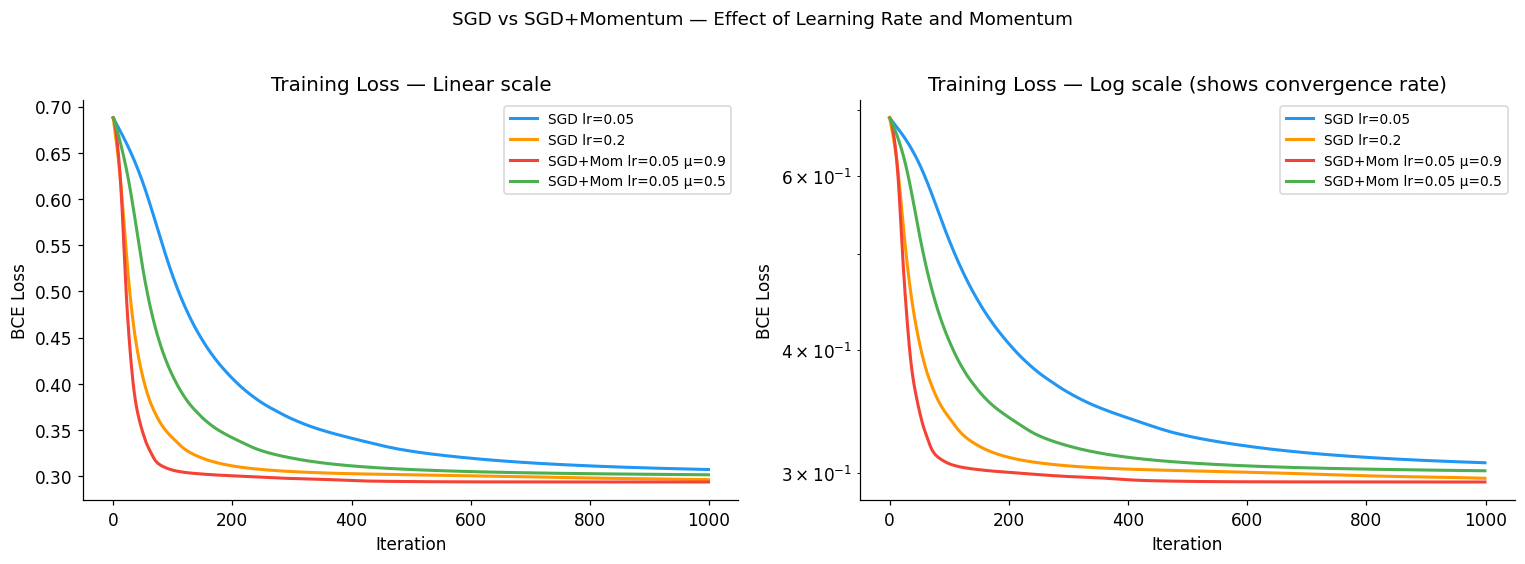

  SGD lr=0.05                          Final loss: 0.30732
  SGD lr=0.2                           Final loss: 0.29635
  SGD+Mom lr=0.05 μ=0.9                Final loss: 0.29382
  SGD+Mom lr=0.05 μ=0.5                Final loss: 0.30160


In [18]:
class SGD:
    def __init__(self, lr=0.05):
        self.lr = lr

    def step(self, params, grads):
        for p, g in zip(params, grads):
            p -= self.lr * g
        return params


class SGDMomentum:
    def __init__(self, lr=0.05, momentum=0.9):
        self.lr       = lr
        self.momentum = momentum
        self.velocity = None

    def step(self, params, grads):
        if self.velocity is None:
            self.velocity = [np.zeros_like(p) for p in params]
        for i, (p, g) in enumerate(zip(params, grads)):
            self.velocity[i] = self.momentum * self.velocity[i] - self.lr * g
            p += self.velocity[i]
        return params


def full_training_run(optim_class, optim_kwargs, X, y, iters=800, seed=SEED):
    """Train ThreeLayerNet with a given optimiser, return loss history."""
    np.random.seed(seed)
    net    = ThreeLayerNet()
    optim  = optim_class(**optim_kwargs)
    losses = []

    for _ in range(iters):
        y_hat  = net.forward(X)
        loss   = -np.mean(y * np.log(y_hat+1e-12) + (1-y)*np.log(1-y_hat+1e-12))
        losses.append(loss)

        grads  = backprop(net, X, y)
        params = [net.W1, net.b1, net.W2, net.b2, net.W3, net.b3]
        gs     = [grads['dW1'], grads['db1'], grads['dW2'],
                  grads['db2'], grads['dW3'], grads['db3']]
        optim.step(params, gs)

    return losses


X_tr, y_tr = X_vis[:400], y_vis[:400]

configs = [
    ('SGD lr=0.05',          SGD,         {'lr': 0.05}),
    ('SGD lr=0.2',           SGD,         {'lr': 0.20}),
    ('SGD+Mom lr=0.05 μ=0.9', SGDMomentum, {'lr': 0.05, 'momentum': 0.9}),
    ('SGD+Mom lr=0.05 μ=0.5', SGDMomentum, {'lr': 0.05, 'momentum': 0.5}),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_colors = [COLORS['pos'], COLORS['accent'], COLORS['neg'], COLORS['green']]

all_losses = {}
for (label, cls, kwargs), col in zip(configs, plot_colors):
    losses = full_training_run(cls, kwargs, X_tr, y_tr, iters=1000)
    all_losses[label] = losses
    axes[0].plot(losses, color=col, lw=2, label=label)
    axes[1].semilogy(losses, color=col, lw=2, label=label)

for ax in axes:
    ax.set_xlabel('Iteration')
    ax.set_ylabel('BCE Loss')
    ax.legend(fontsize=9)

axes[0].set_title('Training Loss — Linear scale')
axes[1].set_title('Training Loss — Log scale (shows convergence rate)')

plt.suptitle('SGD vs SGD+Momentum — Effect of Learning Rate and Momentum',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

for label, losses in all_losses.items():
    print(f"  {label:<35}  Final loss: {losses[-1]:.5f}")


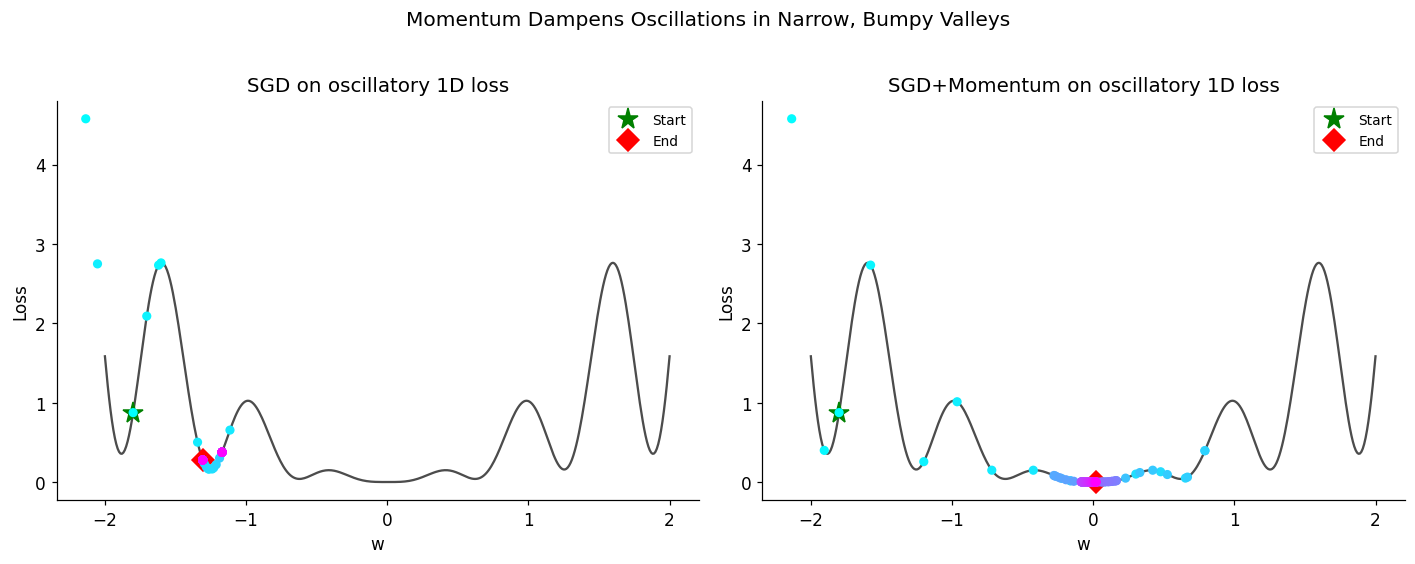

Colour = iteration (purple=early, yellow=late)
Momentum smooths the trajectory by accumulating gradient history.


In [19]:
# ── Visual: momentum dampens oscillations ────────────────────────────────────
# Simulate 1D loss L(w) = w^2 * sin(5w) + 0.2w^2 (oscillatory valley)
def toy_loss(w): return w**2 * np.sin(5*w)**2 + 0.1*w**2
def toy_grad(w): return 2*w*np.sin(5*w)**2 + w**2 * 2*np.sin(5*w)*np.cos(5*w)*5 + 0.2*w

w_range = np.linspace(-2, 2, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SGD path
w_sgd, w_mom = -1.8, -1.8
v_mom = 0.0
lr, mu = 0.03, 0.9

path_sgd, path_mom = [w_sgd], [w_mom]
for _ in range(80):
    w_sgd -= lr * toy_grad(w_sgd)
    v_mom  = mu * v_mom - lr * toy_grad(w_mom)
    w_mom += v_mom
    path_sgd.append(w_sgd); path_mom.append(w_mom)

for ax, path, label, col in [
    (axes[0], path_sgd, 'SGD',          COLORS['pos']),
    (axes[1], path_mom, 'SGD+Momentum', COLORS['accent']),
]:
    ax.plot(w_range, [toy_loss(w) for w in w_range], 'k-', lw=1.5, alpha=0.7)
    steps = np.array(path)
    ax.scatter(steps, [toy_loss(w) for w in steps], c=range(len(steps)),
               cmap='cool', s=25, zorder=5)
    ax.plot(steps[0], toy_loss(steps[0]), '*', ms=14, color='green', label='Start')
    ax.plot(steps[-1], toy_loss(steps[-1]), 'D', ms=10, color='red', label='End')
    ax.set_xlabel('w'); ax.set_ylabel('Loss')
    ax.set_title(f'{label} on oscillatory 1D loss')
    ax.legend(fontsize=9)

plt.suptitle('Momentum Dampens Oscillations in Narrow, Bumpy Valleys', y=1.02)
plt.tight_layout()
plt.show()
print("Colour = iteration (purple=early, yellow=late)")
print("Momentum smooths the trajectory by accumulating gradient history.")


---
## Section 14 — Batch Sizes: Full-Batch, Mini-Batch, and Stochastic

### Three regimes

| Name | Batch size | Gradient estimate | Speed | Noise |
|------|-----------|------------------|-------|-------|
| **Full-batch (GD)** | $N$ (all data) | Exact | Slow per epoch | None |
| **Mini-batch SGD** | $32$–$256$ | Low-variance estimate | Fast | Moderate |
| **Stochastic (SGD)** | $1$ | Single-sample estimate | Very fast | High |

### Why noise can help

Counter-intuitively, noisy gradients (small batches) can **escape sharp minima**  
and find **flatter, better-generalising minima**.  
This is empirically well-established: large-batch training often finds sharper minima  
that generalise worse (Keskar et al., 2017).

### Practical default: mini-batch with size 32–128

- GPU utilisation is good for batch sizes that fill memory
- Gradient noise is controlled but present
- DataLoader default: `batch_size=32`


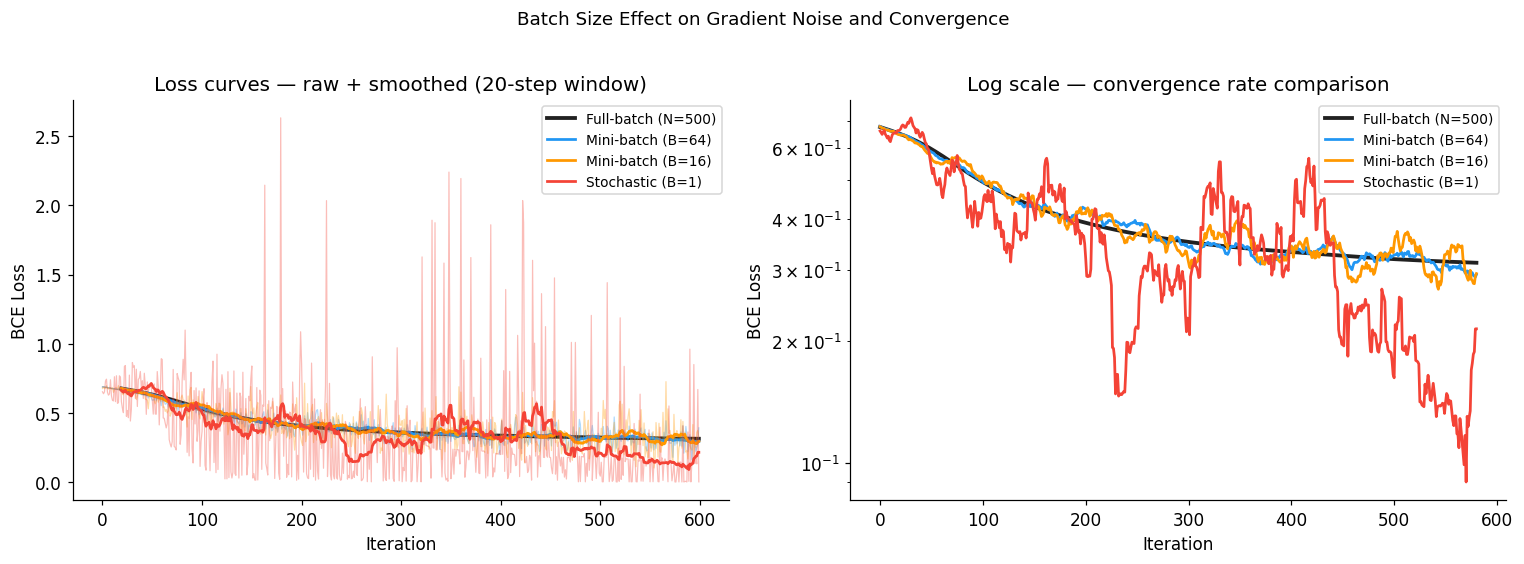

Observations:
  Full-batch:  smooth descent, but each step is expensive
  Mini-batch:  good balance — this is what PyTorch DataLoader gives you
  Stochastic:  noisy but can escape local minima; usually impractical alone


In [20]:
def train_with_batch_size(batch_size, X, y, lr=0.05, iters=600, seed=SEED):
    """
    batch_size = -1 → full batch
    batch_size =  1 → true SGD
    otherwise   → mini-batch
    """
    np.random.seed(seed)
    net    = ThreeLayerNet()
    N      = len(y)
    losses = []

    for it in range(iters):
        # Select batch
        if batch_size == -1 or batch_size >= N:
            Xb, yb = X, y
        else:
            idx = np.random.choice(N, batch_size, replace=False)
            Xb, yb = X[idx], y[idx]

        y_hat  = net.forward(Xb)
        loss   = -np.mean(yb * np.log(y_hat+1e-12) + (1-yb)*np.log(1-y_hat+1e-12))
        losses.append(loss)

        grads = backprop(net, Xb, yb)
        for p, g in [('W1','dW1'),('b1','db1'),('W2','dW2'),
                      ('b2','db2'),('W3','dW3'),('b3','db3')]:
            setattr(net, p, getattr(net, p) - lr * grads[g])

    return losses


X_b, y_b = X_vis[:500], y_vis[:500]

batch_configs = {
    'Full-batch (N=500)':    -1,
    'Mini-batch (B=64)':     64,
    'Mini-batch (B=16)':     16,
    'Stochastic (B=1)':       1,
}
batch_colors = [COLORS['line'], COLORS['pos'], COLORS['accent'], COLORS['neg']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
iters = 600

for (label, bs), col in zip(batch_configs.items(), batch_colors):
    ls_raw = train_with_batch_size(bs, X_b, y_b, iters=iters)
    # Smooth for visibility
    window = 20
    ls_smooth = np.convolve(ls_raw, np.ones(window)/window, mode='valid')
    lw = 2.5 if 'Full' in label else 1.8
    axes[0].plot(ls_raw,    color=col, lw=0.8, alpha=0.35)
    axes[0].plot(range(window-1, len(ls_raw)), ls_smooth, color=col, lw=lw, label=label)
    axes[1].semilogy(ls_smooth, color=col, lw=lw, label=label)

for ax in axes:
    ax.set_xlabel('Iteration')
    ax.set_ylabel('BCE Loss')
    ax.legend(fontsize=9)

axes[0].set_title('Loss curves — raw + smoothed (20-step window)')
axes[1].set_title('Log scale — convergence rate comparison')

plt.suptitle('Batch Size Effect on Gradient Noise and Convergence',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Observations:")
print("  Full-batch:  smooth descent, but each step is expensive")
print("  Mini-batch:  good balance — this is what PyTorch DataLoader gives you")
print("  Stochastic:  noisy but can escape local minima; usually impractical alone")


---
## Summary & What's Next

### What you built in this notebook

| Component | What you wrote |
|-----------|---------------|
| Logistic regression | Forward pass, BCE loss, gradient descent |
| Overfitting demo | Polynomial features, train/test gap |
| Single hidden-layer net | Matrix dimensions, forward pass |
| Two hidden-layer net | Full forward pass with shape trace |
| Manifold transformation | Layer-by-layer space warping, PCA projection |
| Chain rule | Full symbolic derivation + numerical check |
| Weight initialisation | Symmetry breaking, He vs Xavier vs zero |
| Computation graph | Forward trace with named intermediates |
| Autodiff engine | Reverse-mode autodiff in ~80 lines |
| Gradient vanishing | Sigmoid saturation, depth × 0.25 bound |
| Loss functions | BCE vs MSE — gradients, saturation |
| Loss landscape | 2D contour plot, optimiser trajectories |
| SGD & Momentum | Implementation + trajectory comparison |
| Batch sizes | Full / mini / stochastic — noise tradeoff |

### The 1:1 mapping to PyTorch

Everything you wrote manually maps directly:

```python
# What you wrote in NumPy          # PyTorch equivalent
sigmoid(z)                         torch.sigmoid(z)
relu(z)                            torch.relu(z)
net.forward(X)                     model(X)
backprop(net, X, y)                loss.backward()
W -= lr * dW                       optimizer.step()
SGDMomentum(lr, momentum)          torch.optim.SGD(lr, momentum)
```

### Next: Notebook 3 — Generalisation in Depth

Covers: bias-variance decomposition, L1/L2 regularisation,  
dropout, batch normalisation, learning rate schedules, and  
the full training loop wired to the MVTec metal-nut dataset.
